# Realistic Simulation Improvements

**Goal:** Bridge the sim-to-real gap by investigating why simulated trajectories are
much smoother than real ones and adding:

1. **Observation (measurement) noise** - sensor jitter present in every real sensor
2. **Process noise** - unmodeled dynamics (road roughness, wind gusts, tire temperature)
3. **More realistic braking scenarios** - higher torques, ABS-like modulation, combined braking+steering
4. **Side-by-side comparison** of before/after vs real data

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import sys
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from pathlib import Path

from simulation.VehicleModel import default_params, vehicle_RK4x, vehicle_fy, radius_tire
from simulation.simulation import (
    rollout_with_states, controls_to_array, make_shuffled_U,
    sample_initial_states, rand_block_brake, rand_block_accel, rand_block_coast,
    controls_from_blocks,
)
from utils.real_data import (
    prep_x_obs_from_df, make_controls_from_df, OBS_LABELS,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 3)

print('JAX devices:', jax.devices())
print('OBS_LABELS:', OBS_LABELS)

c:\Users\aritr\anaconda3\envs\sbi_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX devices: [CpuDevice(id=0)]
OBS_LABELS: ['yaw_rate', 'v_body_x', 'v_body_y', 'a_body_x', 'a_body_y', 'tire_rate_fl', 'tire_rate_fr', 'tire_rate_rl', 'tire_rate_rr']


## 1. Load a Real Braking Trajectory

We pick one full-braking CSV ("Vollbremsung") so we can see the noise and
roughness characteristics of real sensor data.

In [2]:
DATA_DIR = Path('../../data/measurements')
T_EVENT  = 1000
DT       = 0.01

csv_files = sorted(DATA_DIR.glob('*.csv'))
for f in csv_files:
    print(f'  {f.name}')

csv_path = csv_files[0]  # First Asphalt-Vollbremsung
df_real = pd.read_csv(csv_path)
print(f'\nUsing: {csv_path.name}')
print(f'  rows: {len(df_real)}')

# Use last T_EVENT rows to include the actual braking event
start_idx = max(0, len(df_real) - T_EVENT)
x_real = prep_x_obs_from_df(df_real, start_idx, T_EVENT).numpy()  # (T, 9)
u_real = make_controls_from_df(df_real, start_idx, T_EVENT)

print(f'\nReal obs shape: {x_real.shape}')
print(f'Real obs ranges:')
for i, lbl in enumerate(OBS_LABELS):
    col = x_real[:, i]
    print(f'  {lbl:20s}  mean={col.mean():10.4f}  std={col.std():10.4f}  '
          f'min={col.min():10.4f}  max={col.max():10.4f}')

  Jeversen_2021_12_15_112145_Asphalt-Vollbremsung.csv
  Jeversen_2021_12_15_112328_Asphalt-Vollbremsung.csv
  Jeversen_2021_12_15_125650_Beton-Vollbremsung.csv
  Jeversen_2021_12_15_125936_Beton-Vollbremsung.csv
  Jeversen_2021_12_15_134709_Basalt-Vollbremsung.csv
  Jeversen_2021_12_15_134858_Basalt-Vollbremsung.csv
  Jeversen_2022_10_12_110132.csv

Using: Jeversen_2021_12_15_112145_Asphalt-Vollbremsung.csv
  rows: 1070

Real obs shape: (1000, 9)
Real obs ranges:
  yaw_rate              mean=   -0.0000  std=    0.0001  min=   -0.0006  max=    0.0005
  v_body_x              mean=    9.9788  std=   10.2795  min=   -0.3810  max=   23.5530
  v_body_y              mean=    0.0140  std=    0.0193  min=   -0.0280  max=    0.0992
  a_body_x              mean=   -2.5746  std=    3.6456  min=  -13.0905  max=    8.6485
  a_body_y              mean=    0.2198  std=    0.3242  min=   -2.5781  max=    6.3765
  tire_rate_fl          mean=   32.0413  std=   33.2892  min=    0.0000  max=   77.5166
  ti

## 2. Baseline Simulation (Current - No Noise)

Run the current deterministic simulator with default parameters and
the existing braking control recipe.

In [3]:
rng = np.random.default_rng(42)

# Default params
MU  = 0.411
CD  = 1.0
M   = 1500.0
p_inf = jnp.array([MU, CD, M])

# Sample initial state
s0 = sample_initial_states(rng, 1, center_ms=11.0, range_ms=10.0)[0]
print(f'Initial v_x = {float(s0[4]):.2f} m/s = {float(s0[4])*3.6:.1f} km/h')

# Current control recipe
recipe_current = make_shuffled_U(rng, T_EVENT, DT,
                                  brake_block_fraction=0.5, accel_scale=1.2)
u_current = controls_from_blocks(recipe_current, T_seg=T_EVENT, dt=DT,
                                  ramp_s=0.2, steer_scale=0.5)

# Rollout
_, y_baseline = rollout_with_states(p_inf, u_current, state0=s0)
y_baseline_np = np.array(y_baseline)  # (T, 9)

print(f'Baseline sim shape: {y_baseline_np.shape}')
for i, lbl in enumerate(OBS_LABELS):
    col = y_baseline_np[:, i]
    print(f'  {lbl:20s}  mean={col.mean():10.4f}  std={col.std():10.4f}')

Initial v_x = 16.48 m/s = 59.3 km/h
Baseline sim shape: (1000, 9)
  yaw_rate              mean=    0.0461  std=    0.0645
  v_body_x              mean=   12.0306  std=    1.5804
  v_body_y              mean=    3.4065  std=    2.2792
  a_body_x              mean=   -0.2404  std=    1.0080
  a_body_y              mean=    0.0185  std=    0.2334
  tire_rate_fl          mean=   47.6451  std=   12.0825
  tire_rate_fr          mean=   48.0783  std=   12.0807
  tire_rate_rl          mean=   40.4992  std=    4.1822
  tire_rate_rr          mean=   40.7058  std=    3.9826


## 3. Roughness Analysis: Real vs Simulated

We measure **high-frequency content** (timestep-to-timestep differences) to
quantify how much rougher real data is compared to the smooth simulation.

Channel                 Real d-std     Sim d-std     Ratio
------------------------------------------------------------
yaw_rate                  0.000044      0.002275       0.0x
v_body_x                  0.036084      0.010078       3.6x
v_body_y                  0.004192      0.006461       0.6x
a_body_x                  1.546684      0.031380      49.3x
a_body_y                  0.429298      0.059049       7.3x
tire_rate_fl              0.650474      0.132037       4.9x
tire_rate_fr              0.650474      0.131928       4.9x
tire_rate_rl              0.650474      0.034686      18.8x
tire_rate_rr              0.650474      0.031394      20.7x


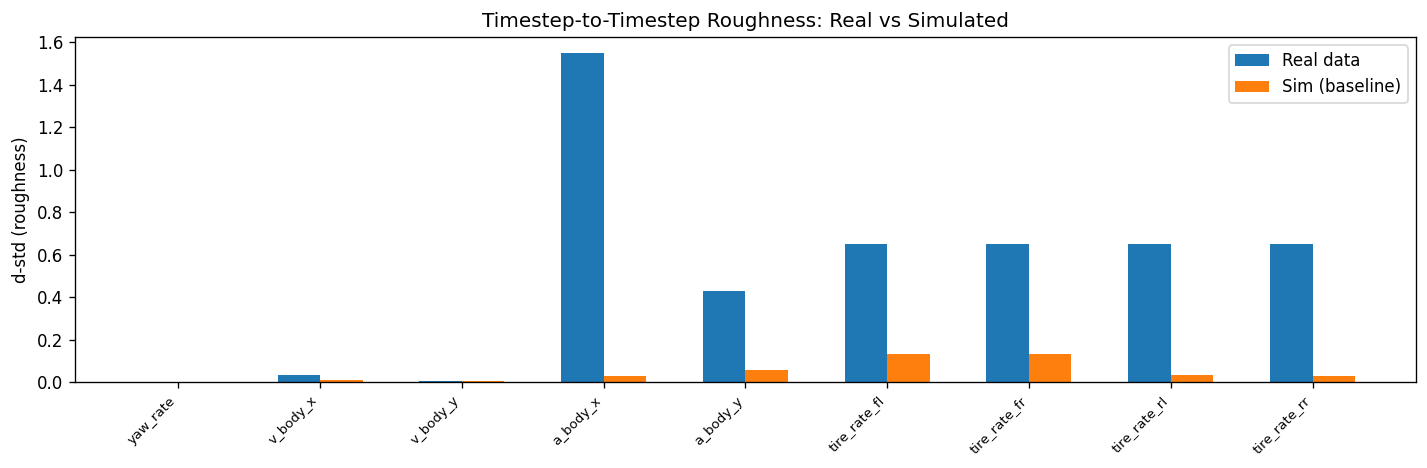

In [4]:
def diff_std(x):
    """Standard deviation of first-differences - measures local roughness."""
    return np.std(np.diff(x, axis=0), axis=0)

rough_real = diff_std(x_real)
rough_sim  = diff_std(y_baseline_np)

print(f'{"Channel":20s}  {"Real d-std":>12s}  {"Sim d-std":>12s}  {"Ratio":>8s}')
print('-' * 60)
for i, lbl in enumerate(OBS_LABELS):
    ratio = rough_real[i] / max(rough_sim[i], 1e-12)
    print(f'{lbl:20s}  {rough_real[i]:12.6f}  {rough_sim[i]:12.6f}  {ratio:8.1f}x')

# Bar chart
fig, ax = plt.subplots(figsize=(12, 4))
x_pos = np.arange(len(OBS_LABELS))
ax.bar(x_pos - 0.15, rough_real, 0.3, label='Real data', color='C0')
ax.bar(x_pos + 0.15, rough_sim, 0.3, label='Sim (baseline)', color='C1')
ax.set_xticks(x_pos)
ax.set_xticklabels(OBS_LABELS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('d-std (roughness)')
ax.set_title('Timestep-to-Timestep Roughness: Real vs Simulated')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Noise Model Calibration from Real Data

We estimate per-channel observation noise by looking at the **high-frequency
residual** after a Savitzky-Golay smoothing of the real signal.

In [5]:
from scipy.signal import savgol_filter

all_noise_stds = []

for csv_path in csv_files:
    df = pd.read_csv(csv_path)
    T_use = min(T_EVENT, len(df))
    start = max(0, len(df) - T_use)
    x_obs = prep_x_obs_from_df(df, start, T_use).numpy()
    
    # Smooth with Savitzky-Golay (window 21 samples = 0.21s, order 3)
    x_smooth = savgol_filter(x_obs, window_length=21, polyorder=3, axis=0)
    residual = x_obs - x_smooth
    noise_std = np.std(residual, axis=0)
    all_noise_stds.append(noise_std)
    print(f'{csv_path.stem[:50]:50s}  range: [{noise_std.min():.5f}, {noise_std.max():.4f}]')

# Average across all files
obs_noise_std = np.mean(all_noise_stds, axis=0)
print(f'\nCalibrated observation noise (averaged over {len(csv_files)} files):')
for i, lbl in enumerate(OBS_LABELS):
    print(f'  {lbl:20s}  noise_std = {obs_noise_std[i]:.6f}')

Jeversen_2021_12_15_112145_Asphalt-Vollbremsung     range: [0.00004, 1.0716]
Jeversen_2021_12_15_112328_Asphalt-Vollbremsung     range: [0.00004, 0.9200]
Jeversen_2021_12_15_125650_Beton-Vollbremsung       range: [0.00004, 0.9579]
Jeversen_2021_12_15_125936_Beton-Vollbremsung       range: [0.00003, 0.8247]
Jeversen_2021_12_15_134709_Basalt-Vollbremsung      range: [0.00007, 1.4307]
Jeversen_2021_12_15_134858_Basalt-Vollbremsung      range: [0.00007, 1.3492]
Jeversen_2022_10_12_110132                          range: [0.00004, 0.8202]

Calibrated observation noise (averaged over 7 files):
  yaw_rate              noise_std = 0.000046
  v_body_x              noise_std = 0.009497
  v_body_y              noise_std = 0.004206
  a_body_x              noise_std = 1.053474
  a_body_y              noise_std = 0.307155
  tire_rate_fl          noise_std = 0.822096
  tire_rate_fr          noise_std = 0.822096
  tire_rate_rl          noise_std = 0.822096
  tire_rate_rr          noise_std = 0.822096


## 5. Add Observation + Process Noise to Simulation

- **Observation noise**: Gaussian noise calibrated from real sensor data
- **Process noise**: Approximate by adding correlated noise to the clean trajectory
  (low-pass filtered to mimic unmodeled dynamics rather than white noise)

In [6]:
def add_observation_noise(y_clean, rng, noise_std):
    """Add per-channel Gaussian sensor noise."""
    noise = rng.normal(0, noise_std, size=y_clean.shape).astype(np.float32)
    return y_clean + noise


def add_process_noise(y_clean, rng, scales, smoothing_window=5):
    """
    Approximate process noise by adding low-pass-filtered random walk
    perturbations to each channel. This mimics slowly-varying unmodeled
    dynamics (road surface changes, tire temp) rather than white noise.
    
    scales: dict mapping channel index -> noise scale
    """
    T, D = y_clean.shape
    y_out = y_clean.copy()
    for ch_idx, scale in scales.items():
        # Random walk
        increments = rng.normal(0, scale, size=T).astype(np.float32)
        walk = np.cumsum(increments)
        # Smooth the walk to remove high-freq artifacts
        if smoothing_window > 1:
            kernel = np.ones(smoothing_window) / smoothing_window
            walk = np.convolve(walk, kernel, mode='same').astype(np.float32)
        y_out[:, ch_idx] += walk
    return y_out


# Process noise scales for key dynamic channels
# idx: 0=dyaw, 1=v_x, 2=v_y, 3=a_x, 4=a_y, 5-8=tire rates
process_noise_scales = {
    0: 0.0005,   # yaw rate [rad/s]
    1: 0.005,    # v_x [m/s]
    2: 0.002,    # v_y [m/s]
    3: 0.01,     # a_x [m/s^2]
    4: 0.005,    # a_y [m/s^2]
    5: 0.02,     # tire_fl [rad/s]
    6: 0.02,     # tire_fr [rad/s]
    7: 0.02,     # tire_rl [rad/s]
    8: 0.02,     # tire_rr [rad/s]
}

# Apply both noise sources
rng2 = np.random.default_rng(42)
y_with_process = add_process_noise(y_baseline_np, rng2, process_noise_scales, smoothing_window=5)
y_full_noisy = add_observation_noise(y_with_process, rng2, obs_noise_std)

print(f'Noisy sim shape: {y_full_noisy.shape}')
rough_noisy = diff_std(y_full_noisy)
print(f'\n{"Channel":20s}  {"Real":>10s}  {"Clean":>10s}  {"Noisy":>10s}  {"Gap closed":>10s}')
print('-' * 70)
for i, lbl in enumerate(OBS_LABELS):
    gap_before = abs(rough_real[i] - rough_sim[i])
    gap_after  = abs(rough_real[i] - rough_noisy[i])
    pct = (1 - gap_after / max(gap_before, 1e-12)) * 100
    print(f'{lbl:20s}  {rough_real[i]:10.5f}  {rough_sim[i]:10.5f}  '
          f'{rough_noisy[i]:10.5f}  {pct:8.1f}%')

Noisy sim shape: (1000, 9)

Channel                     Real       Clean       Noisy  Gap closed
----------------------------------------------------------------------
yaw_rate                 0.00004     0.00227     0.00229      -0.8%
v_body_x                 0.03608     0.01008     0.01728      27.7%
v_body_y                 0.00419     0.00646     0.00899    -111.6%
a_body_x                 1.54668     0.03138     1.55428      99.5%
a_body_y                 0.42930     0.05905     0.43314      99.0%
tire_rate_fl             0.65047     0.13204     1.16321       1.1%
tire_rate_fr             0.65047     0.13193     1.14500       4.6%
tire_rate_rl             0.65047     0.03469     1.18514      13.2%
tire_rate_rr             0.65047     0.03139     1.17846      14.7%


## 6. Visual Comparison: Real vs Baseline vs Noisy

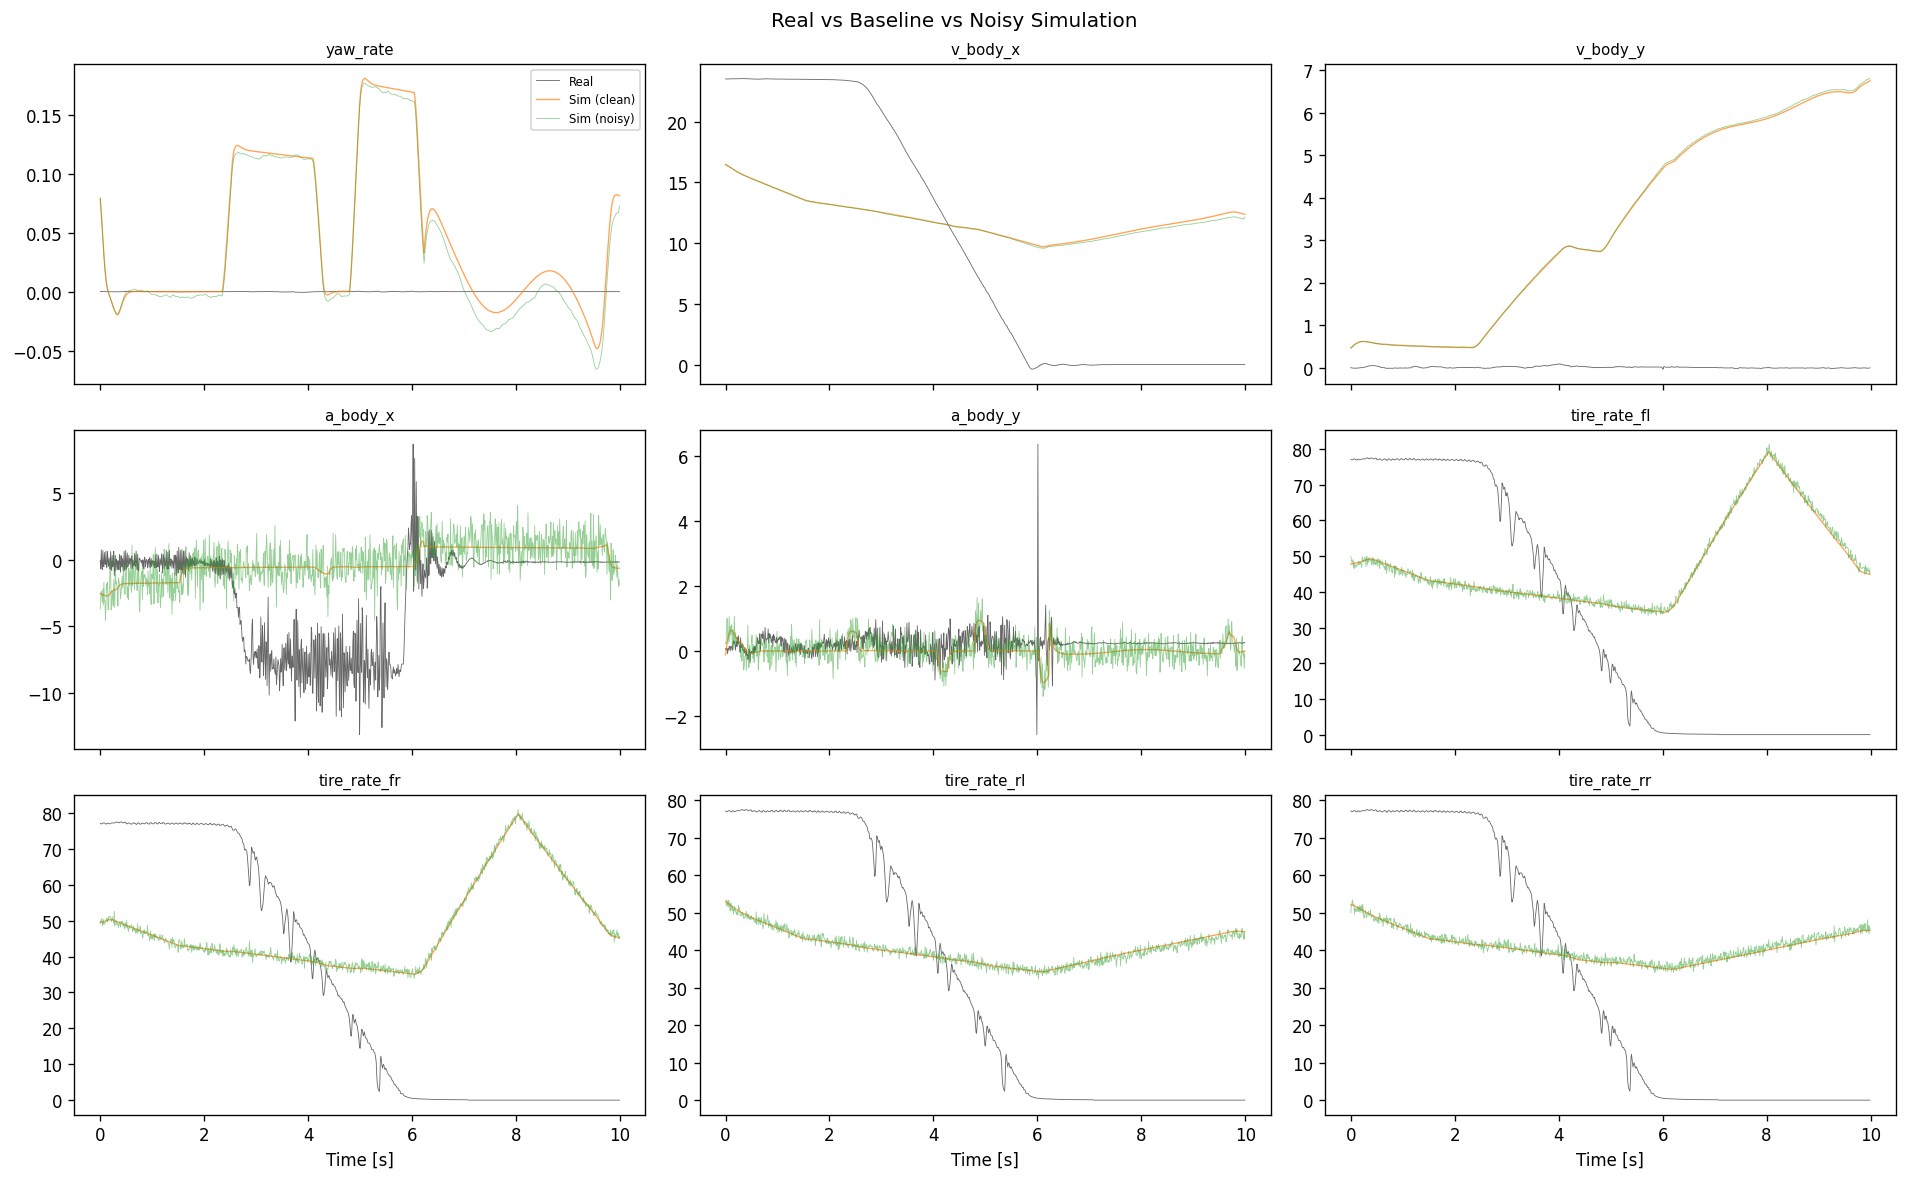

In [7]:
t_axis = np.arange(T_EVENT) * DT

fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for i, lbl in enumerate(OBS_LABELS):
    ax = axes[i]
    ax.plot(t_axis, x_real[:, i], 'k-', alpha=0.6, linewidth=0.5, label='Real')
    ax.plot(t_axis, y_baseline_np[:, i], 'C1-', alpha=0.7, linewidth=0.8, label='Sim (clean)')
    ax.plot(t_axis, y_full_noisy[:, i], 'C2-', alpha=0.5, linewidth=0.5, label='Sim (noisy)')
    ax.set_title(lbl, fontsize=9)
    if i >= 6:
        ax.set_xlabel('Time [s]')
    if i == 0:
        ax.legend(fontsize=7)

fig.suptitle('Real vs Baseline vs Noisy Simulation', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Improved Braking Scenarios

Current braking issues:
- Brake torque range is only 100-250 Nm (too gentle for emergency braking)
- No combined braking + steering (real emergencies involve evasion)
- No ABS-like modulation (real brake pressure oscillates at ~15 Hz during ABS)

We define new block types using the **same block dict format** as the existing code.

In [8]:
def rand_block_emergency_brake(rng):
    """Emergency full-braking with much higher torques."""
    brk = float(rng.uniform(350, 600))  # Much higher than current 100-250
    duty = float(rng.uniform(0.7, 1.0))  # Near-full duty
    dur = float(rng.uniform(1.0, 4.0))   # Longer braking events
    gear = int(rng.integers(2, 6))
    return {
        'dur_s': dur,
        'engine': ('step', {'value': 0.0, 'duty': 0.0}),
        'brake': ('step', {'value': brk, 'duty': duty}),
        'steer': ('flat', {'value': 0.0}),
        'gear': ('flat', {'value': gear}),
    }


def rand_block_brake_and_steer(rng):
    """Combined braking + evasive steering (panic swerve)."""
    brk = float(rng.uniform(200, 500))
    duty = float(rng.uniform(0.5, 1.0))
    steer_deg = float(rng.uniform(8, 25))  # Larger than normal
    freq = float(rng.uniform(0.3, 1.0))    # Slower swerve
    dur = float(rng.uniform(1.5, 3.5))
    gear = int(rng.integers(2, 6))
    return {
        'dur_s': dur,
        'engine': ('step', {'value': 0.0, 'duty': 0.0}),
        'brake': ('step', {'value': brk, 'duty': duty}),
        'steer': ('sine', {'amp': np.deg2rad(steer_deg), 'freq_hz': freq, 'phase': 0.0}),
        'gear': ('flat', {'value': gear}),
    }


def rand_block_coast_with_disturbance(rng):
    """Coasting with road disturbance (small random steering input)."""
    dur = float(rng.uniform(1.0, 3.0))
    steer_deg = float(rng.uniform(0.5, 3.0))
    freq = float(rng.uniform(1.0, 3.0))  # Higher freq = road input
    gear = int(rng.integers(3, 6))
    return {
        'dur_s': dur,
        'engine': ('step', {'value': 0.0, 'duty': 0.0}),
        'brake': ('step', {'value': 0.0, 'duty': 0.0}),
        'steer': ('sine', {'amp': np.deg2rad(steer_deg), 'freq_hz': freq, 'phase': 0.0}),
        'gear': ('flat', {'value': gear}),
    }


print('New block types defined.')

New block types defined.


In [9]:
def make_improved_recipe(rng, total_T, dt):
    """
    Build an improved control recipe with more diverse braking scenarios.
    
    Mix:
      - 8 accel blocks
      - 3 normal coast + 3 coast with disturbance
      - 4 normal brakes
      - 3 emergency brakes (high torque)
      - 2 combined brake+steer
    """
    pieces = []

    for _ in range(8):
        pieces.append(rand_block_accel(rng, accel_scale=1.2))
    for _ in range(3):
        pieces.append(rand_block_coast(rng))
    for _ in range(3):
        pieces.append(rand_block_coast_with_disturbance(rng))
    for _ in range(4):
        pieces.append(rand_block_brake(rng))
    for _ in range(3):
        pieces.append(rand_block_emergency_brake(rng))
    for _ in range(2):
        pieces.append(rand_block_brake_and_steer(rng))

    rng.shuffle(pieces)

    # Trim to total time
    blocks, tsum = [], 0.0
    for b in pieces:
        blocks.append(b)
        tsum += b['dur_s']
        if tsum >= total_T * dt:
            break
    return blocks


# Build improved controls
rng3 = np.random.default_rng(123)

# Higher initial speed for emergency braking
s0_fast = sample_initial_states(rng3, 1, center_ms=18.0, range_ms=5.0)[0]
print(f'Initial v_x = {float(s0_fast[4]):.2f} m/s = {float(s0_fast[4])*3.6:.1f} km/h')

recipe_improved = make_improved_recipe(rng3, T_EVENT, DT)
u_improved = controls_from_blocks(recipe_improved, T_seg=T_EVENT, dt=DT,
                                   ramp_s=0.1, steer_scale=0.5)

print(f'\nImproved controls:')
for k, v in u_improved.items():
    v_np = np.array(v)
    print(f'  {k:25s}  shape={v_np.shape}  '
          f'range=[{v_np.min():.2f}, {v_np.max():.2f}]')

Initial v_x = 19.82 m/s = 71.4 km/h

Improved controls:
  steer_ang                  shape=(1000,)  range=[-0.20, 0.20]
  engine_torque              shape=(1000,)  range=[0.00, 556.74]
  break_torque               shape=(1000,)  range=[0.00, 367.77]
  gear_transmission          shape=(1000,)  range=[3.00, 5.00]


In [10]:
# Run improved simulation (clean + noisy)
_, y_improved_clean_jnp = rollout_with_states(p_inf, u_improved, state0=s0_fast)
y_improved_clean = np.array(y_improved_clean_jnp)

rng4 = np.random.default_rng(99)
y_improved_proc = add_process_noise(y_improved_clean, rng4, process_noise_scales, smoothing_window=5)
y_improved_noisy = add_observation_noise(y_improved_proc, rng4, obs_noise_std)

print(f'Improved sim shape: {y_improved_noisy.shape}')
rough_improved = diff_std(y_improved_noisy)
rough_improved_clean = diff_std(y_improved_clean)
print(f'\n{"Channel":20s}  {"Real":>10s}  {"Improved clean":>14s}  {"Improved noisy":>14s}')
print('-' * 65)
for i, lbl in enumerate(OBS_LABELS):
    print(f'{lbl:20s}  {rough_real[i]:10.5f}  {rough_improved_clean[i]:14.5f}  '
          f'{rough_improved[i]:14.5f}')

Improved sim shape: (1000, 9)

Channel                     Real  Improved clean  Improved noisy
-----------------------------------------------------------------
yaw_rate                 0.00004         0.00317         0.00320
v_body_x                 0.03608         0.00798         0.01590
v_body_y                 0.00419         0.00944         0.01134
a_body_x                 1.54668         0.01875         1.45119
a_body_y                 0.42930         0.06067         0.44878
tire_rate_fl             0.65047         0.20573         1.17694
tire_rate_fr             0.65047         0.20618         1.19836
tire_rate_rl             0.65047         0.03111         1.16386
tire_rate_rr             0.65047         0.03200         1.17720


## 8. Compare Control Profiles: Current vs Improved

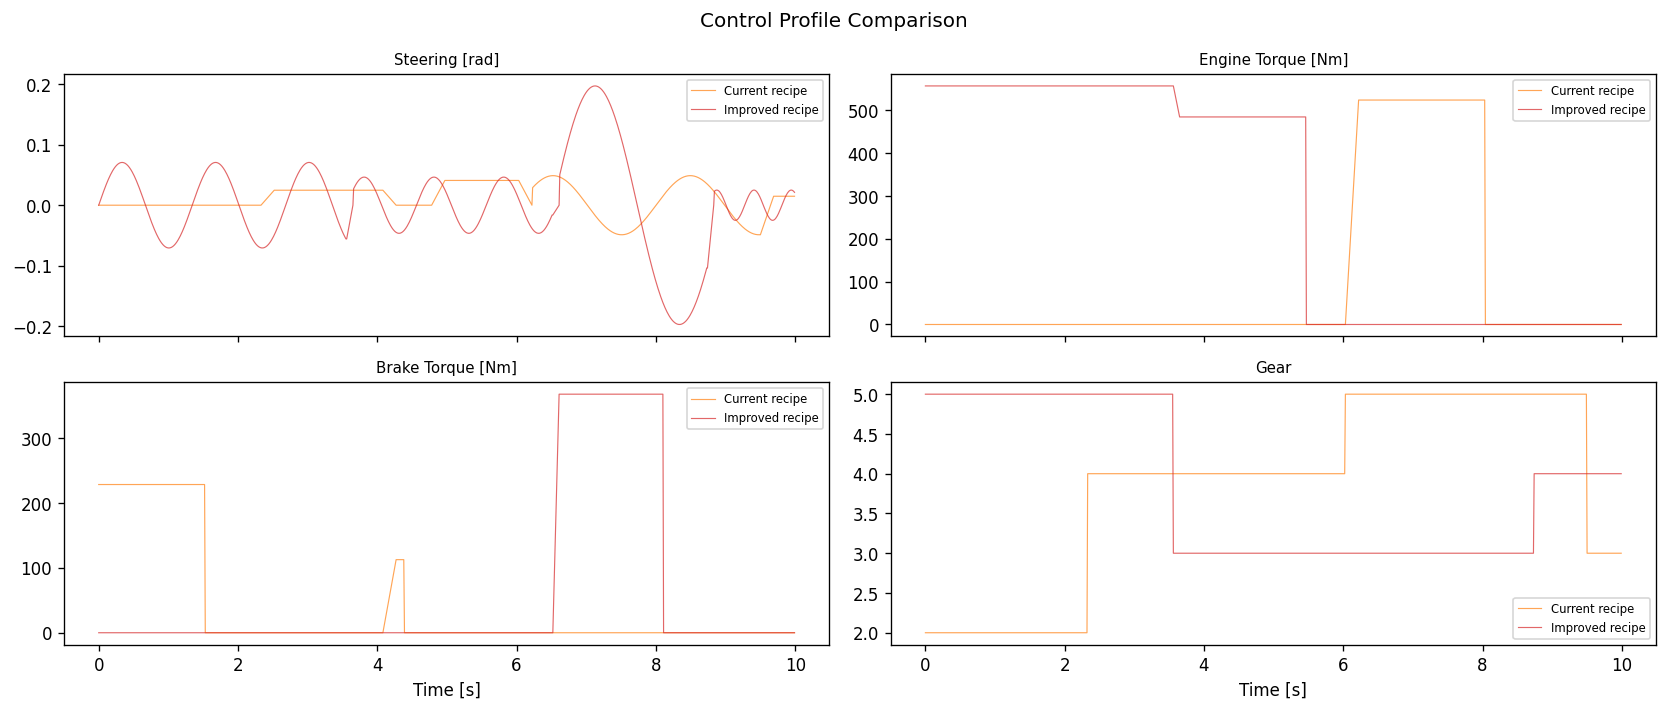

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex=True)
channels = ['steer_ang', 'engine_torque', 'break_torque', 'gear_transmission']
titles = ['Steering [rad]', 'Engine Torque [Nm]', 'Brake Torque [Nm]', 'Gear']

for ax, ch, title in zip(axes.flatten(), channels, titles):
    ax.plot(t_axis, np.array(u_current[ch]), 'C1-', alpha=0.7,
            linewidth=0.7, label='Current recipe')
    ax.plot(t_axis, np.array(u_improved[ch]), 'C3-', alpha=0.7,
            linewidth=0.7, label='Improved recipe')
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)

axes[1, 0].set_xlabel('Time [s]')
axes[1, 1].set_xlabel('Time [s]')
fig.suptitle('Control Profile Comparison', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Full Comparison: Current Clean vs Improved Noisy vs Real

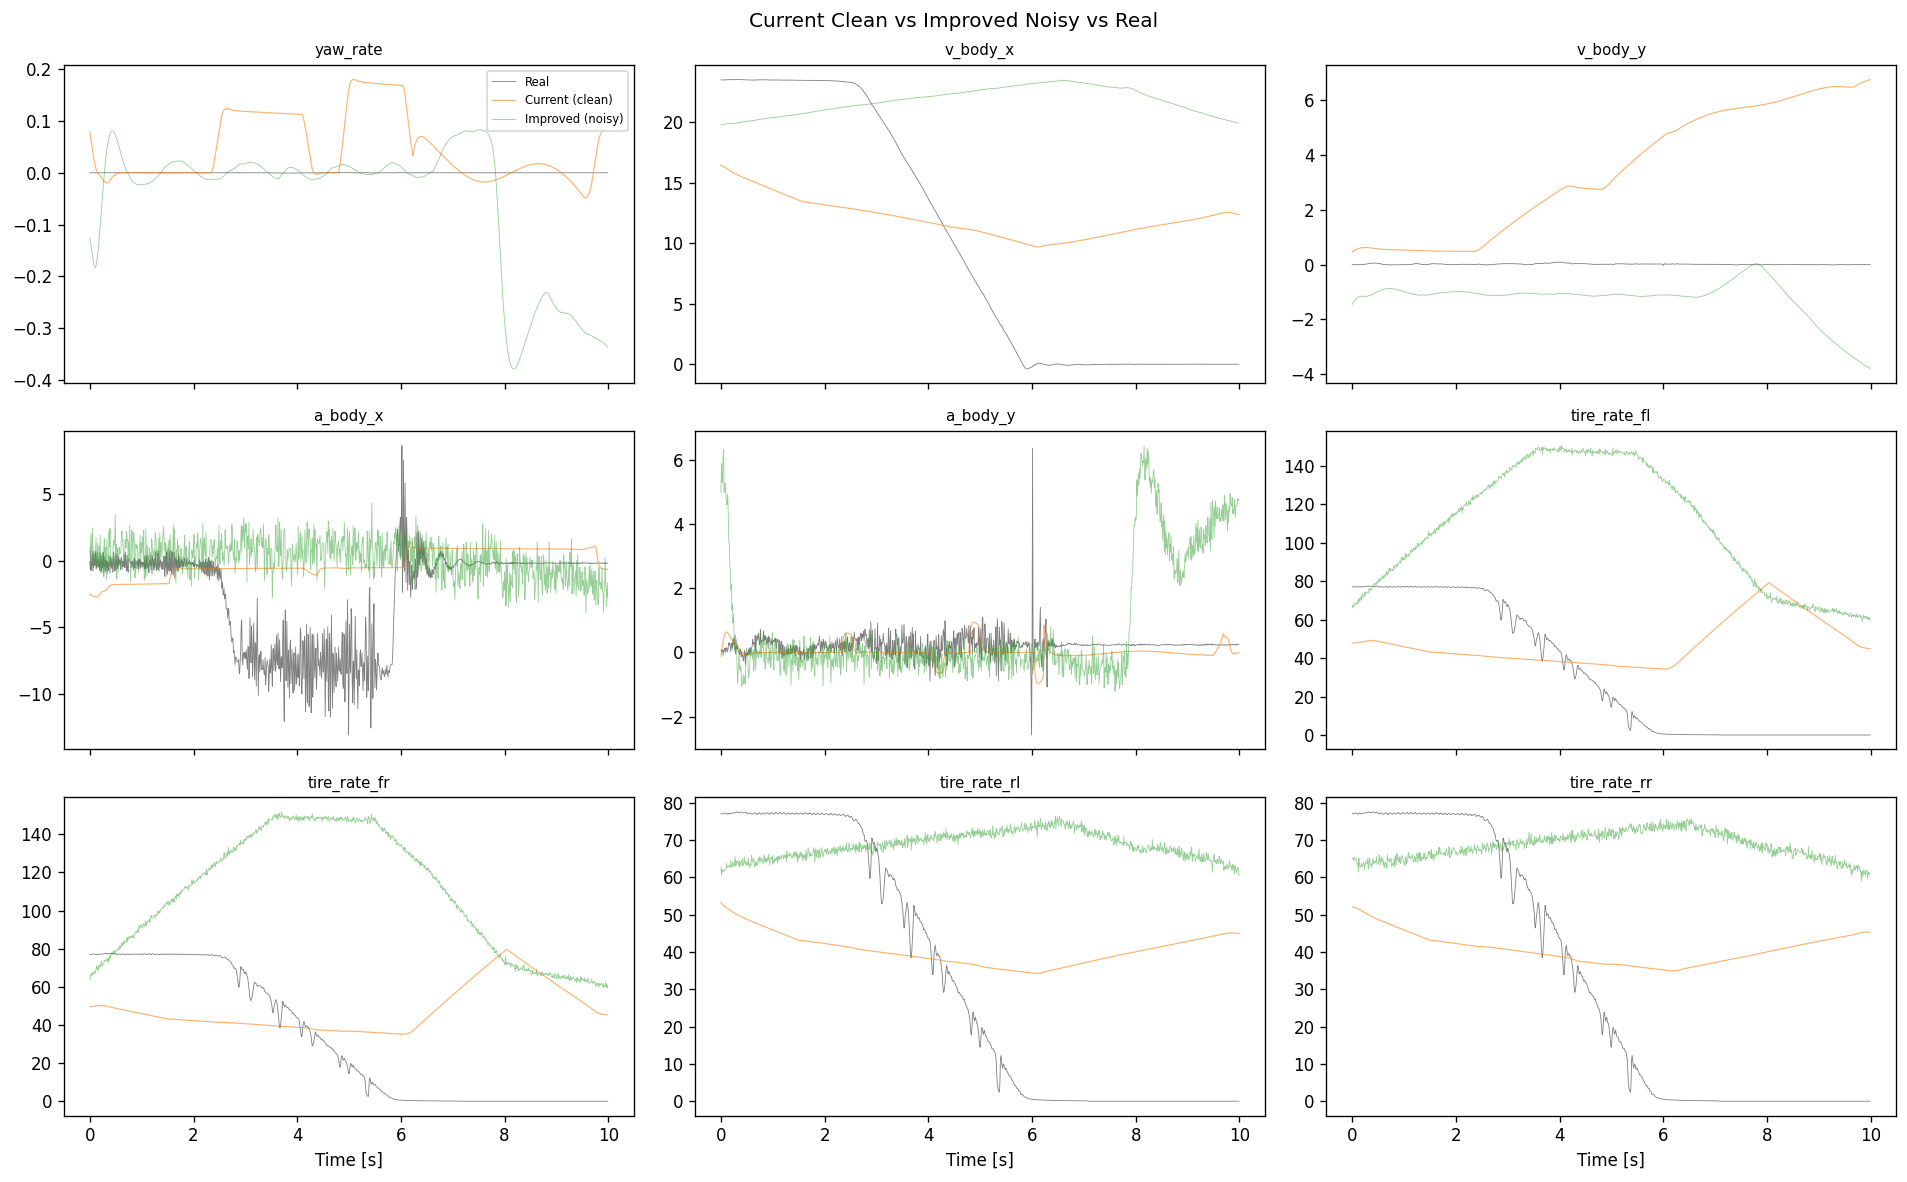

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for i, lbl in enumerate(OBS_LABELS):
    ax = axes[i]
    ax.plot(t_axis, x_real[:, i], 'k-', alpha=0.5, linewidth=0.5, label='Real')
    ax.plot(t_axis, y_baseline_np[:, i], 'C1-', alpha=0.6, linewidth=0.7,
            label='Current (clean)')
    ax.plot(t_axis, y_improved_noisy[:, i], 'C2-', alpha=0.5, linewidth=0.5,
            label='Improved (noisy)')
    ax.set_title(lbl, fontsize=9)
    if i >= 6:
        ax.set_xlabel('Time [s]')
    if i == 0:
        ax.legend(fontsize=7, loc='upper right')

fig.suptitle('Current Clean vs Improved Noisy vs Real', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Power Spectral Density Comparison

The PSD shows whether the frequency content of the improved simulation matches
real data better, especially at high frequencies where the current sim rolls off.

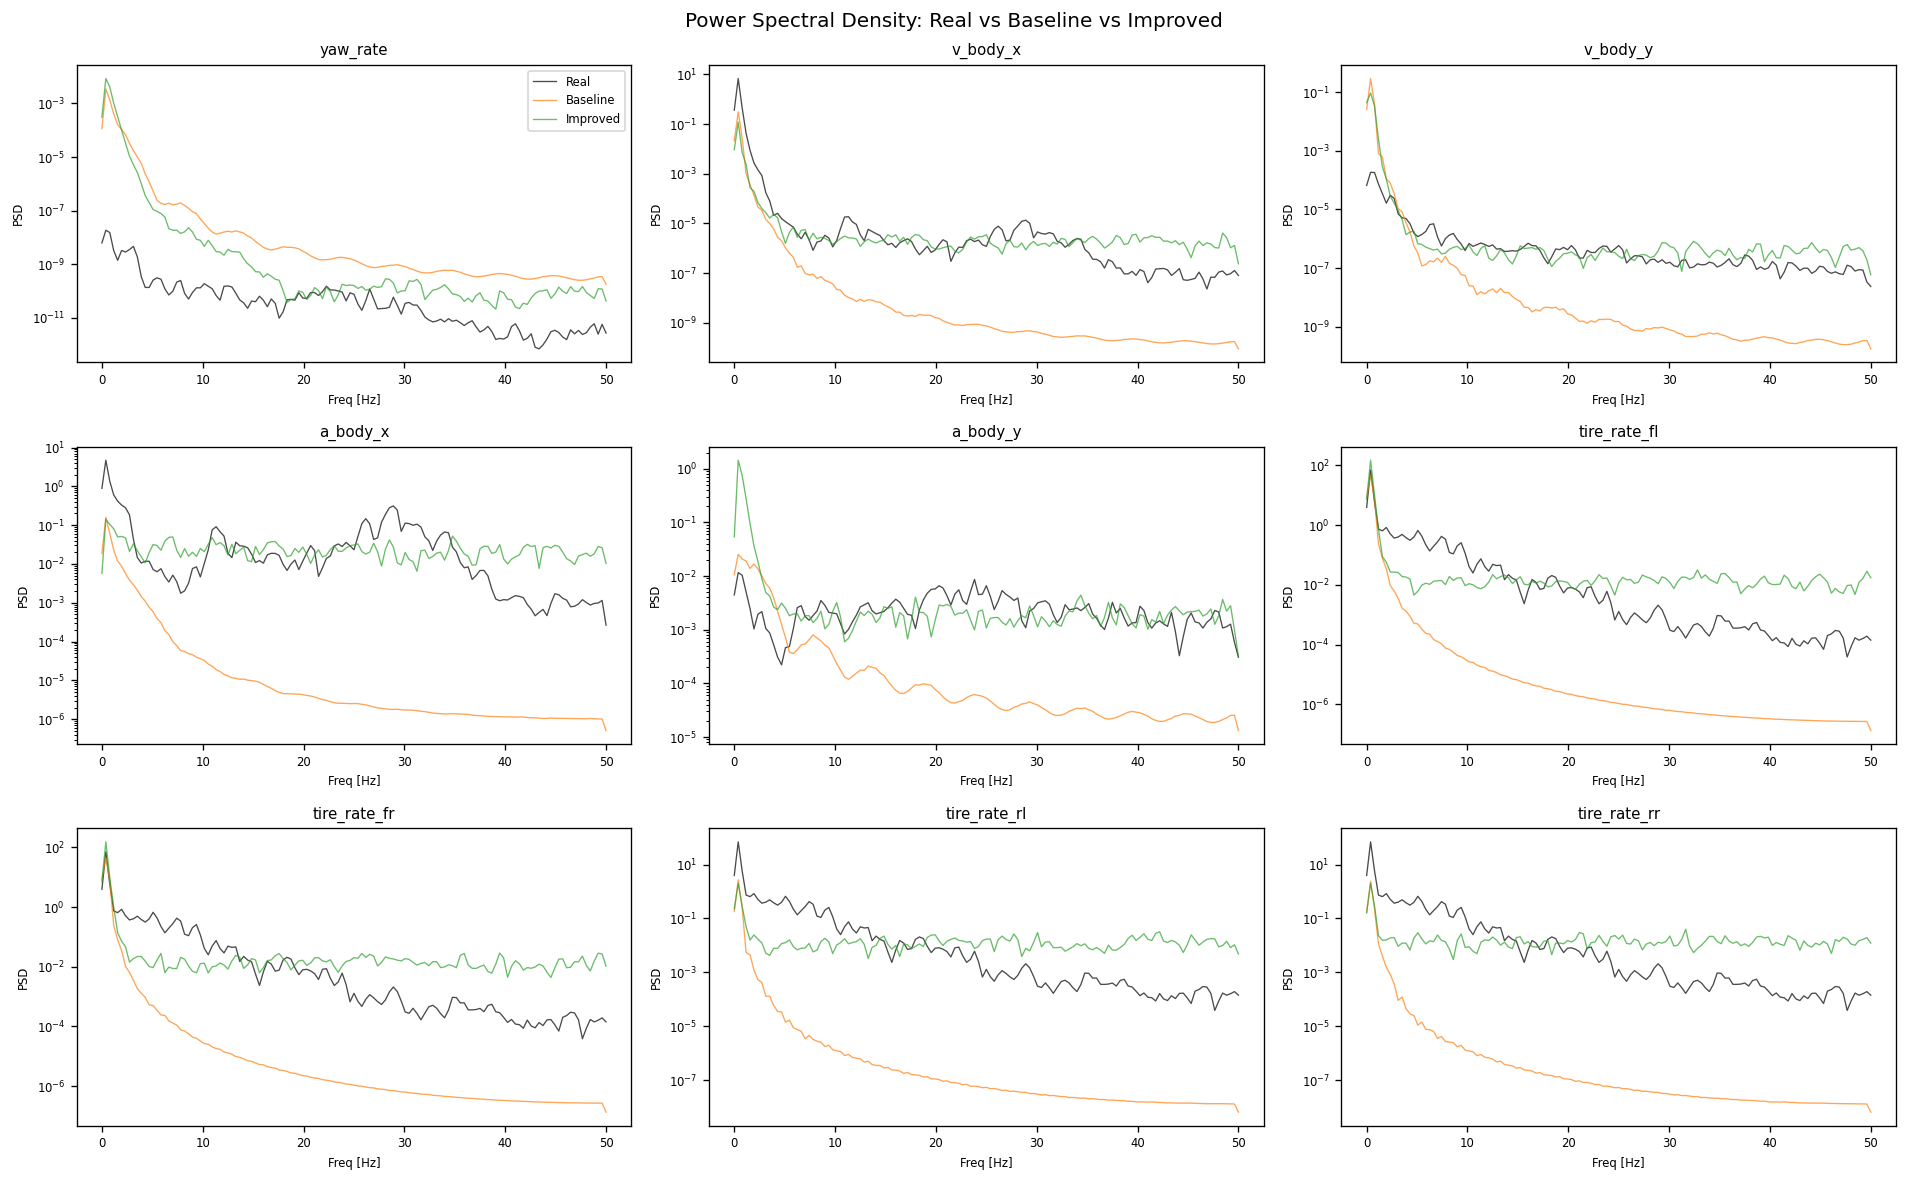

In [13]:
from scipy.signal import welch

fs = 1.0 / DT  # 100 Hz

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for i, lbl in enumerate(OBS_LABELS):
    ax = axes[i]
    f_r, psd_r = welch(x_real[:, i], fs=fs, nperseg=256)
    f_b, psd_b = welch(y_baseline_np[:, i], fs=fs, nperseg=256)
    f_n, psd_n = welch(y_improved_noisy[:, i], fs=fs, nperseg=256)

    ax.semilogy(f_r, psd_r, 'k-', alpha=0.7, linewidth=0.8, label='Real')
    ax.semilogy(f_b, psd_b, 'C1-', alpha=0.7, linewidth=0.8, label='Baseline')
    ax.semilogy(f_n, psd_n, 'C2-', alpha=0.7, linewidth=0.8, label='Improved')
    ax.set_title(lbl, fontsize=9)
    ax.set_xlabel('Freq [Hz]', fontsize=7)
    ax.set_ylabel('PSD', fontsize=7)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

fig.suptitle('Power Spectral Density: Real vs Baseline vs Improved', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Summary Statistics

In [14]:
def compute_stats(x, label):
    return {
        'source': label,
        'mean': x.mean(axis=0),
        'std': x.std(axis=0),
        'roughness': diff_std(x),
    }

stats_list = [
    compute_stats(x_real, 'Real'),
    compute_stats(y_baseline_np, 'Baseline (clean)'),
    compute_stats(y_full_noisy, 'Baseline + noise'),
    compute_stats(y_improved_noisy, 'Improved (noisy)'),
]

for ch_idx, lbl in enumerate(OBS_LABELS):
    print(f'\n=== {lbl} ===')
    print(f'{"Source":25s}  {"Mean":>10s}  {"Std":>10s}  {"Roughness":>10s}')
    for st in stats_list:
        print(f'{st["source"]:25s}  {st["mean"][ch_idx]:10.4f}  '
              f'{st["std"][ch_idx]:10.4f}  {st["roughness"][ch_idx]:10.6f}')


=== yaw_rate ===
Source                           Mean         Std   Roughness
Real                          -0.0000      0.0001    0.000044
Baseline (clean)               0.0461      0.0645    0.002275
Baseline + noise               0.0388      0.0668    0.002292
Improved (noisy)              -0.0551      0.1303    0.003199

=== v_body_x ===
Source                           Mean         Std   Roughness
Real                           9.9788     10.2795    0.036084
Baseline (clean)              12.0306      1.5804    0.010078
Baseline + noise              11.9276      1.6254    0.017277
Improved (noisy)              21.8025      1.0954    0.015900

=== v_body_y ===
Source                           Mean         Std   Roughness
Real                           0.0140      0.0193    0.004192
Baseline (clean)               3.4065      2.2792    0.006461
Baseline + noise               3.4295      2.2988    0.008993
Improved (noisy)              -1.2350      0.7148    0.011343

=== a_body_x ==

## 12. Recommendations for Production Code

### A. Add to `simulation/simulation.py`:
1. `rand_block_emergency_brake()` - brake torques 300-600 Nm
2. `rand_block_brake_and_steer()` - combined braking + evasive steering
3. `rand_block_coast_with_disturbance()` - coasting with road disturbance
4. Update `make_shuffled_U()` to include these new blocks
5. Lower `ramp_s` default from 0.2 to 0.1 for snappier transitions

### B. Add noise utility (e.g. `simulation/noise.py`):
1. `add_observation_noise(y, rng, noise_std)` - calibrated sensor noise
2. `add_process_noise(y, rng, scales)` - random walk perturbation
3. Store calibrated `OBS_NOISE_STD` as a constant

### C. Update `configs/config.py`:
1. Add `obs_noise_std` - per-channel noise std
2. Add `process_noise_scales` - per-channel process noise
3. Add `emergency_brake_fraction` - fraction of emergency blocks

---
## 13. Real Trajectory Comparison (PSO-style)

For each real CSV we:
1. Extract the **real observations** and **real controls**
2. Derive the **initial state from the first real observation** (`initial_state_from_obs`)
3. Forward-simulate with `rollout_with_states` using real controls → **Clean Sim**
4. Apply calibrated process + observation noise → **Noisy Sim**
5. Plot all 9 channels side-by-side and compute per-channel RMSE

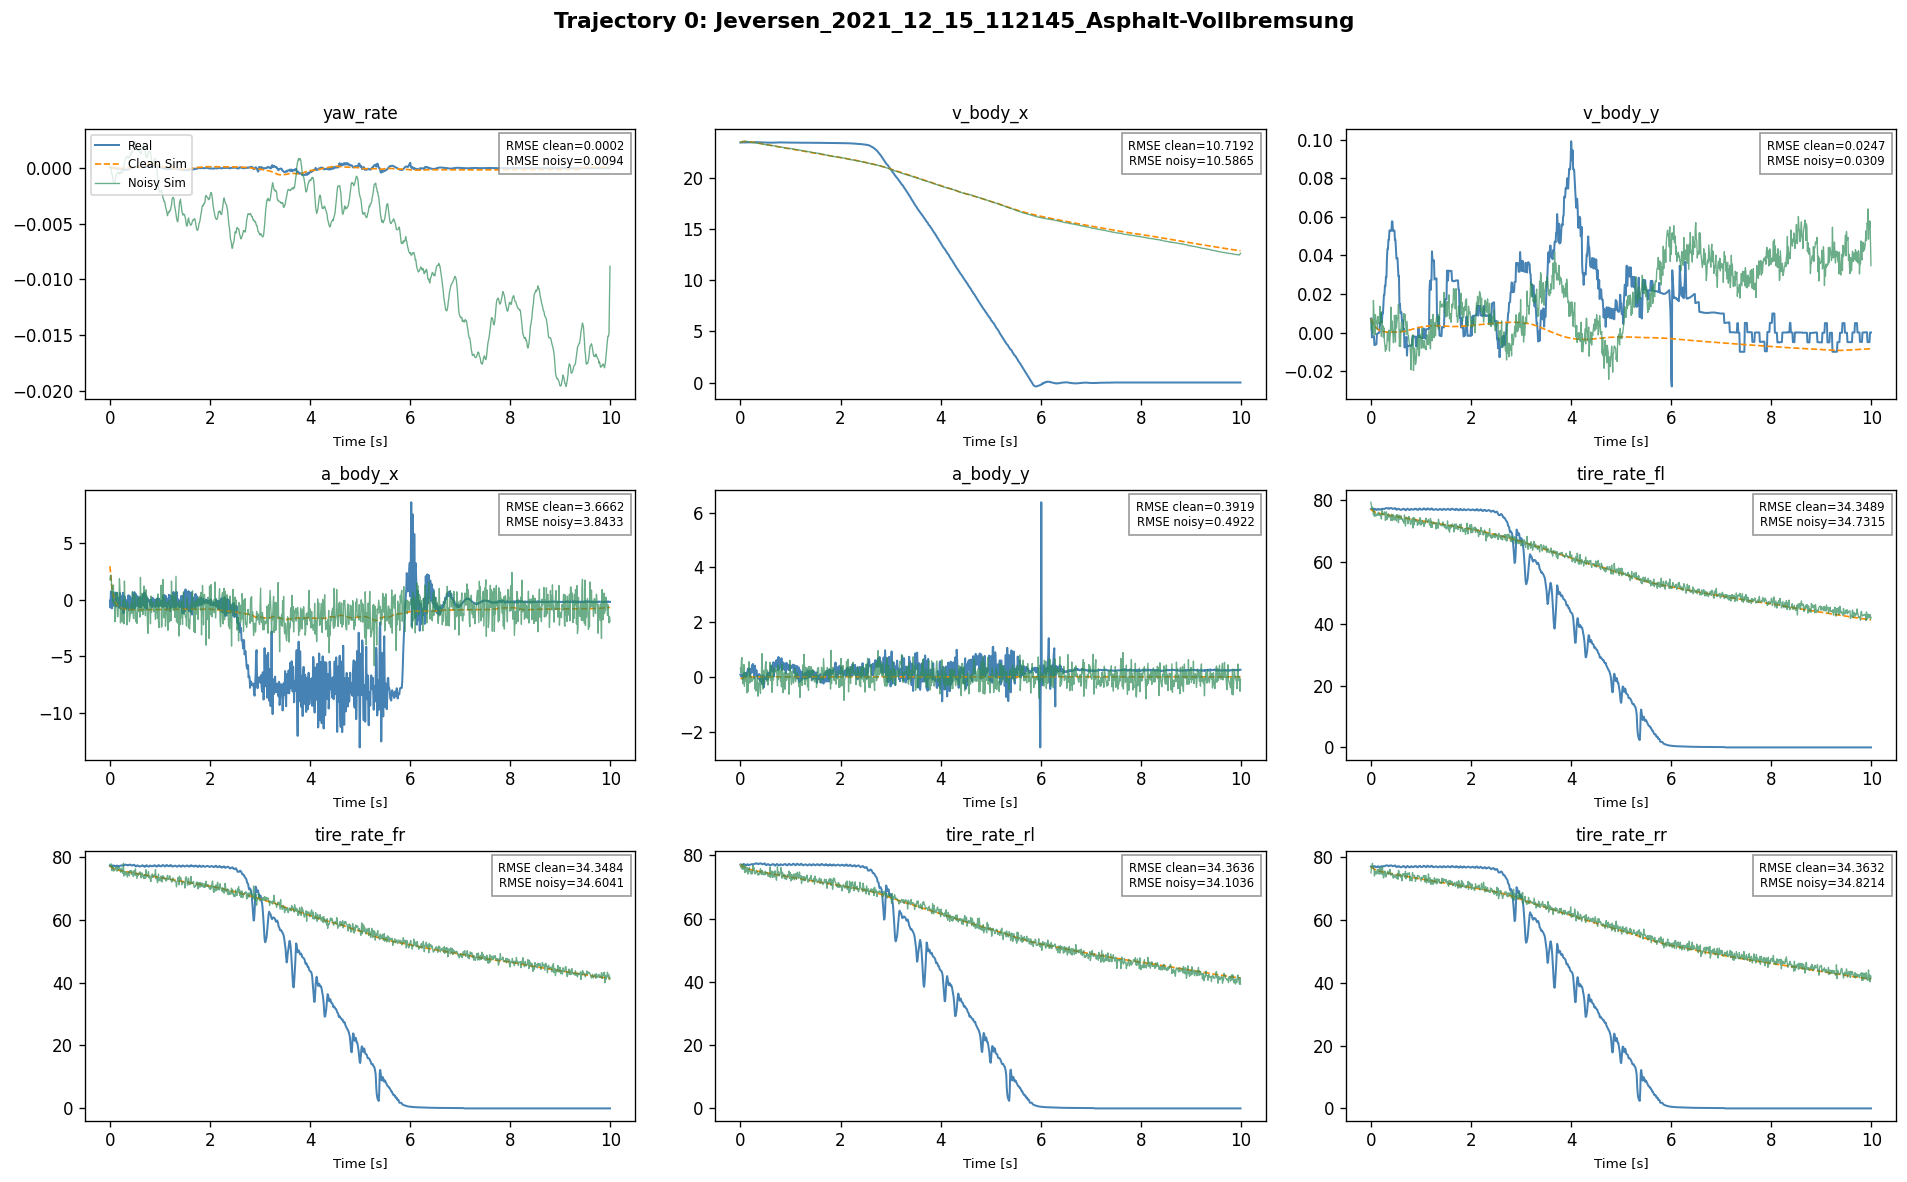


[Jeversen_2021_12_15_112145_Asphalt-Vollbremsung]  Weighted MSE  CleanSim=1640.618048  NoisySim=1658.676276


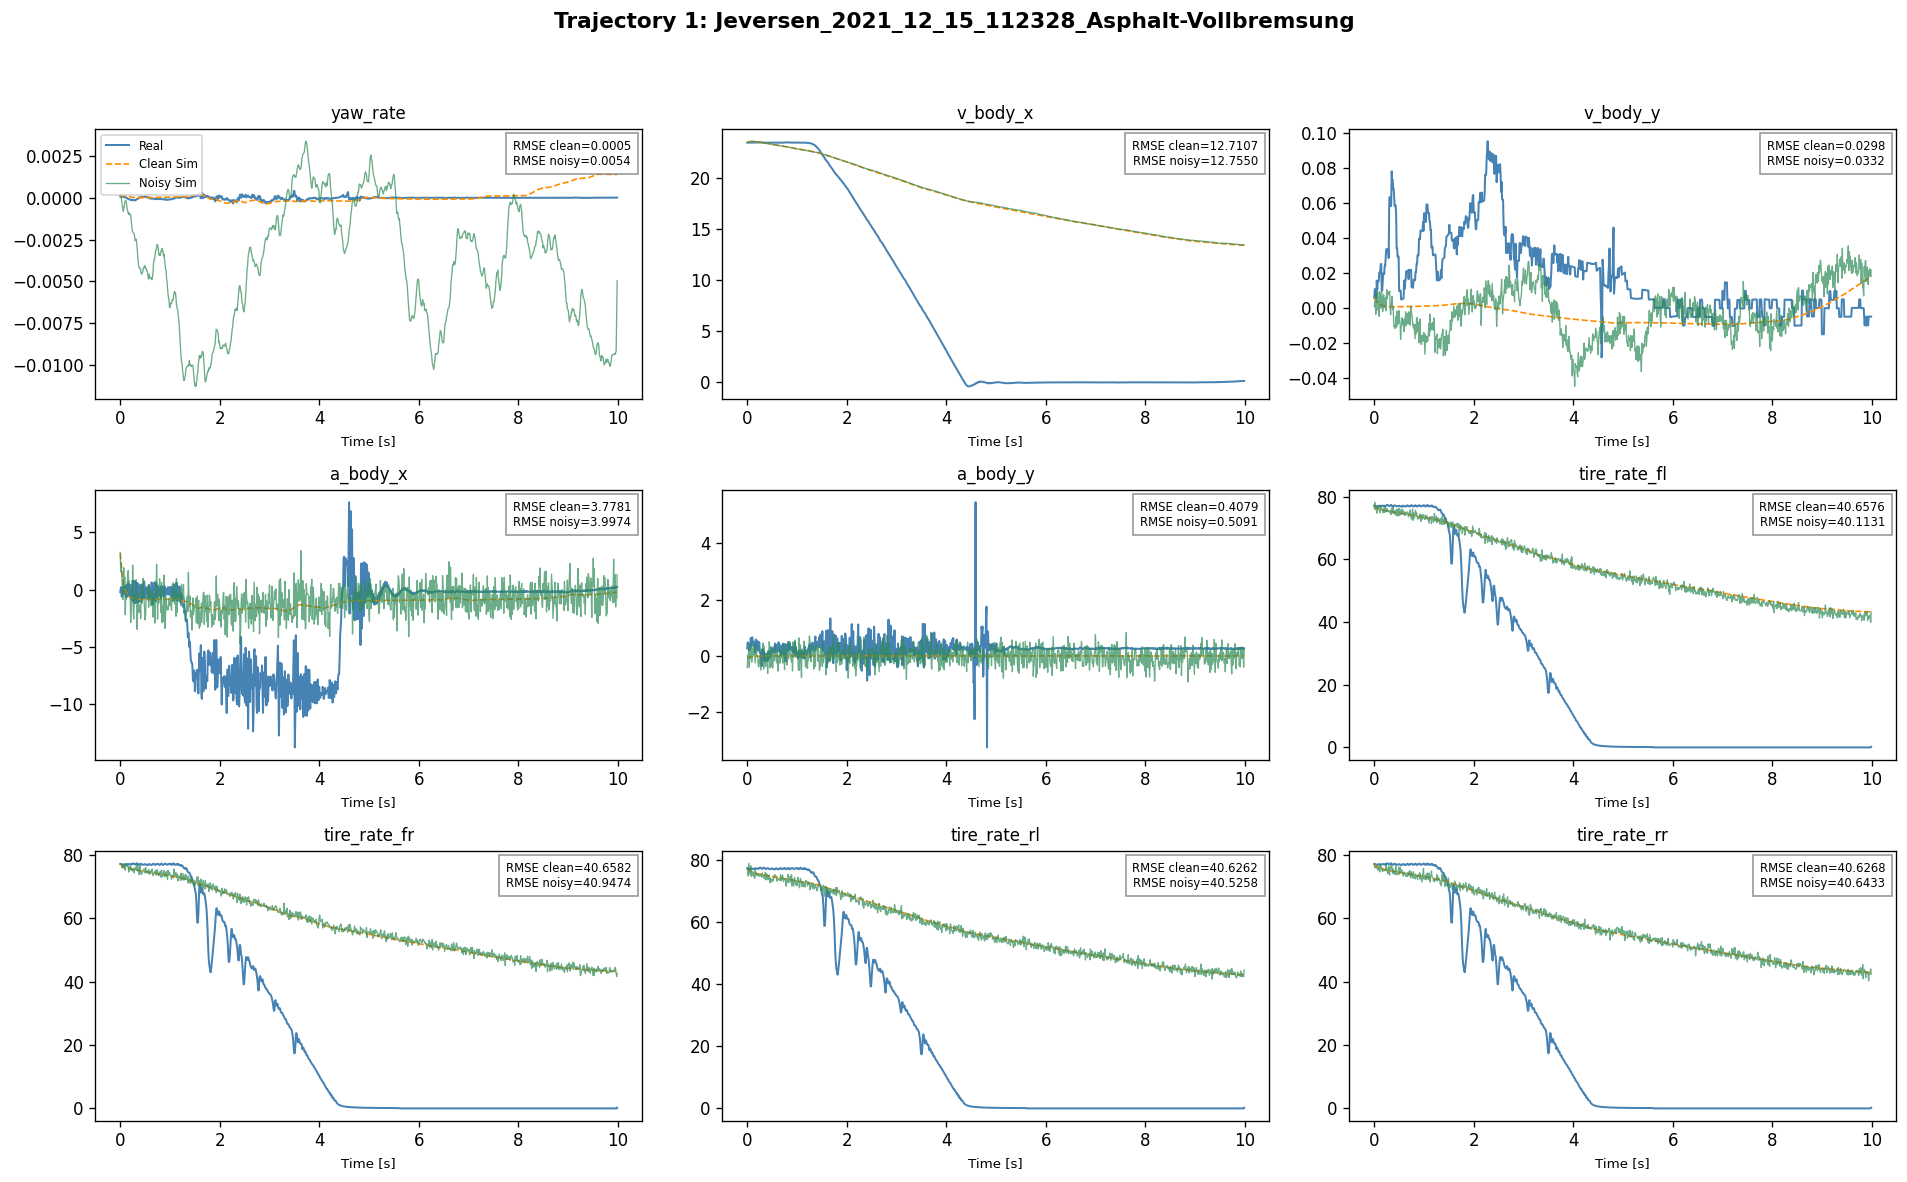


[Jeversen_2021_12_15_112328_Asphalt-Vollbremsung]  Weighted MSE  CleanSim=2295.333942  NoisySim=2287.283043


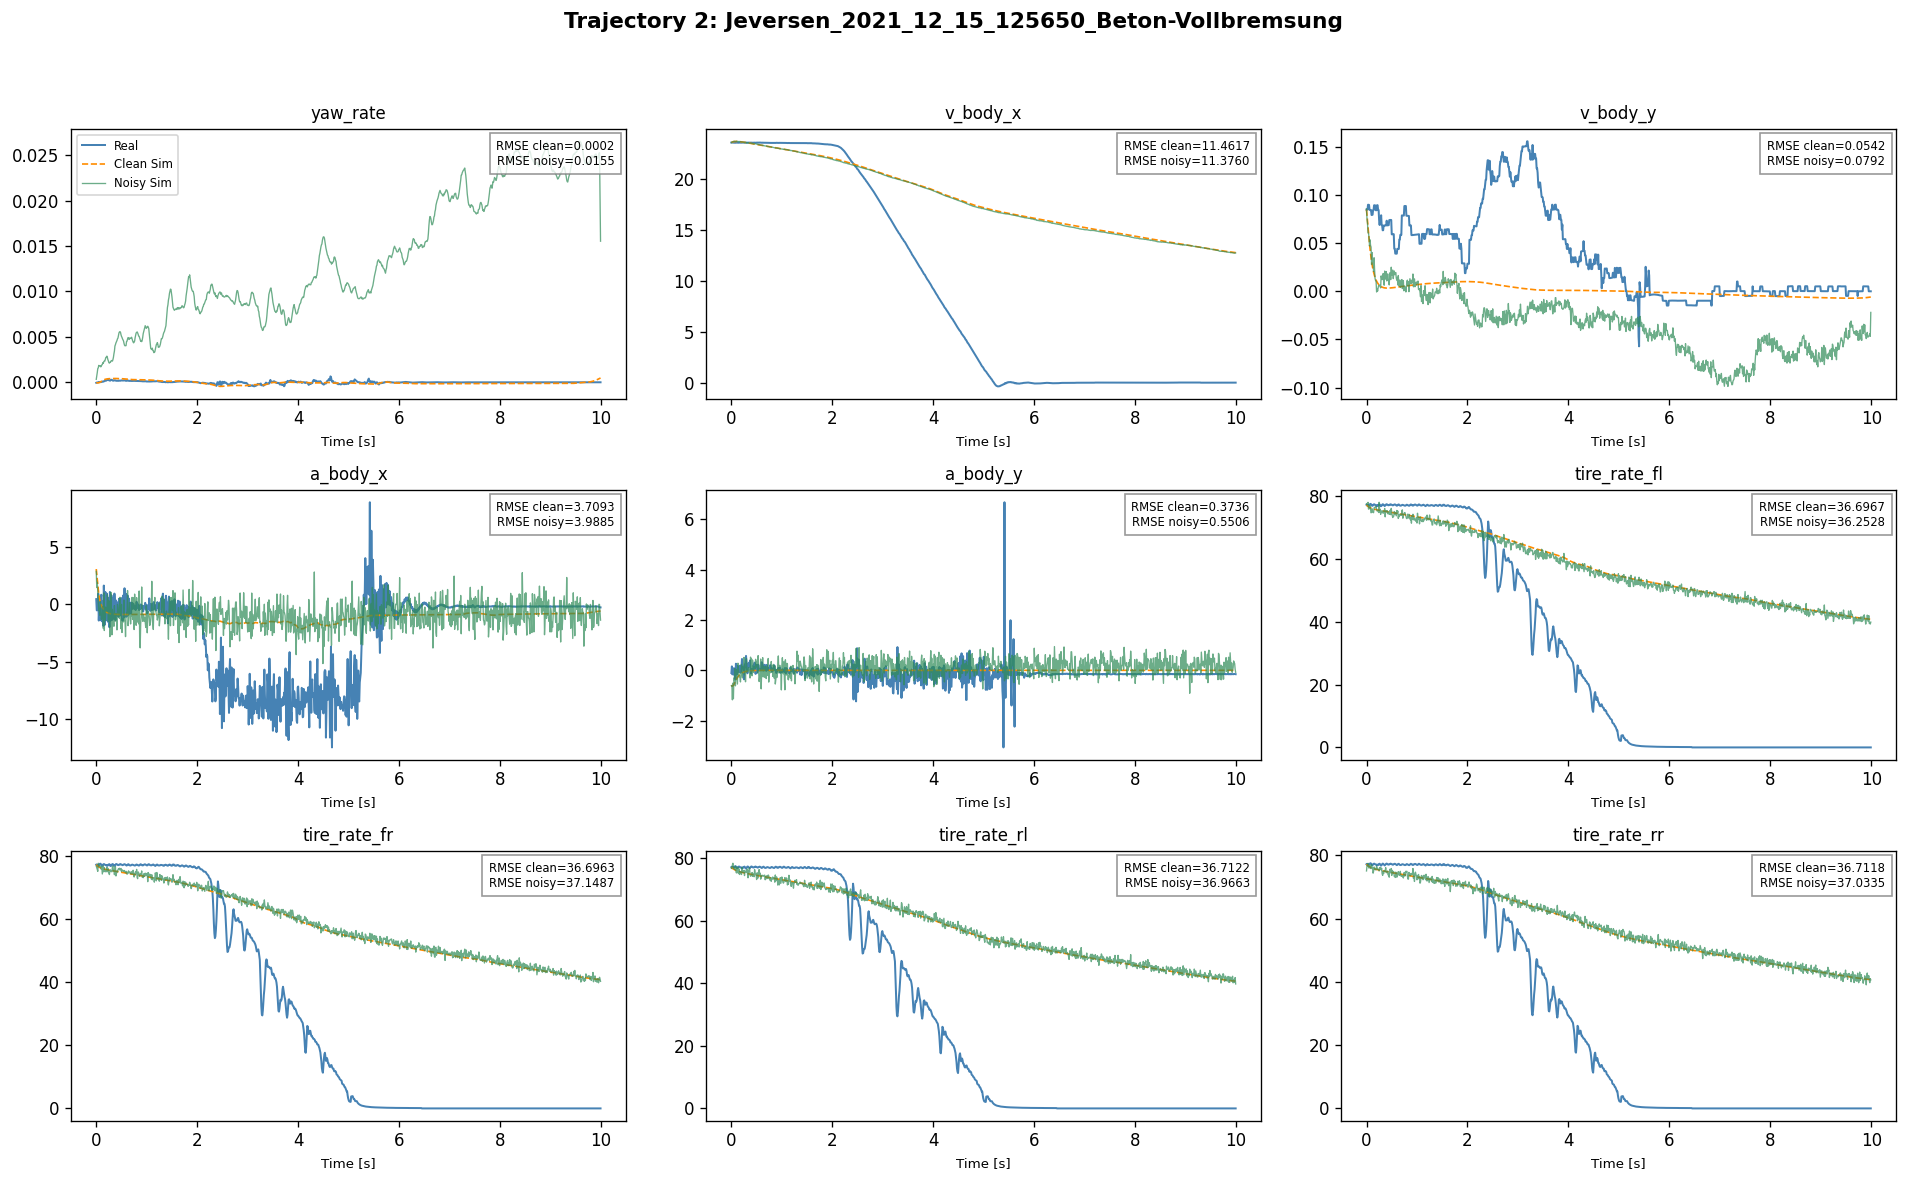


[Jeversen_2021_12_15_125650_Beton-Vollbremsung]  Weighted MSE  CleanSim=1872.327026  NoisySim=1886.223085


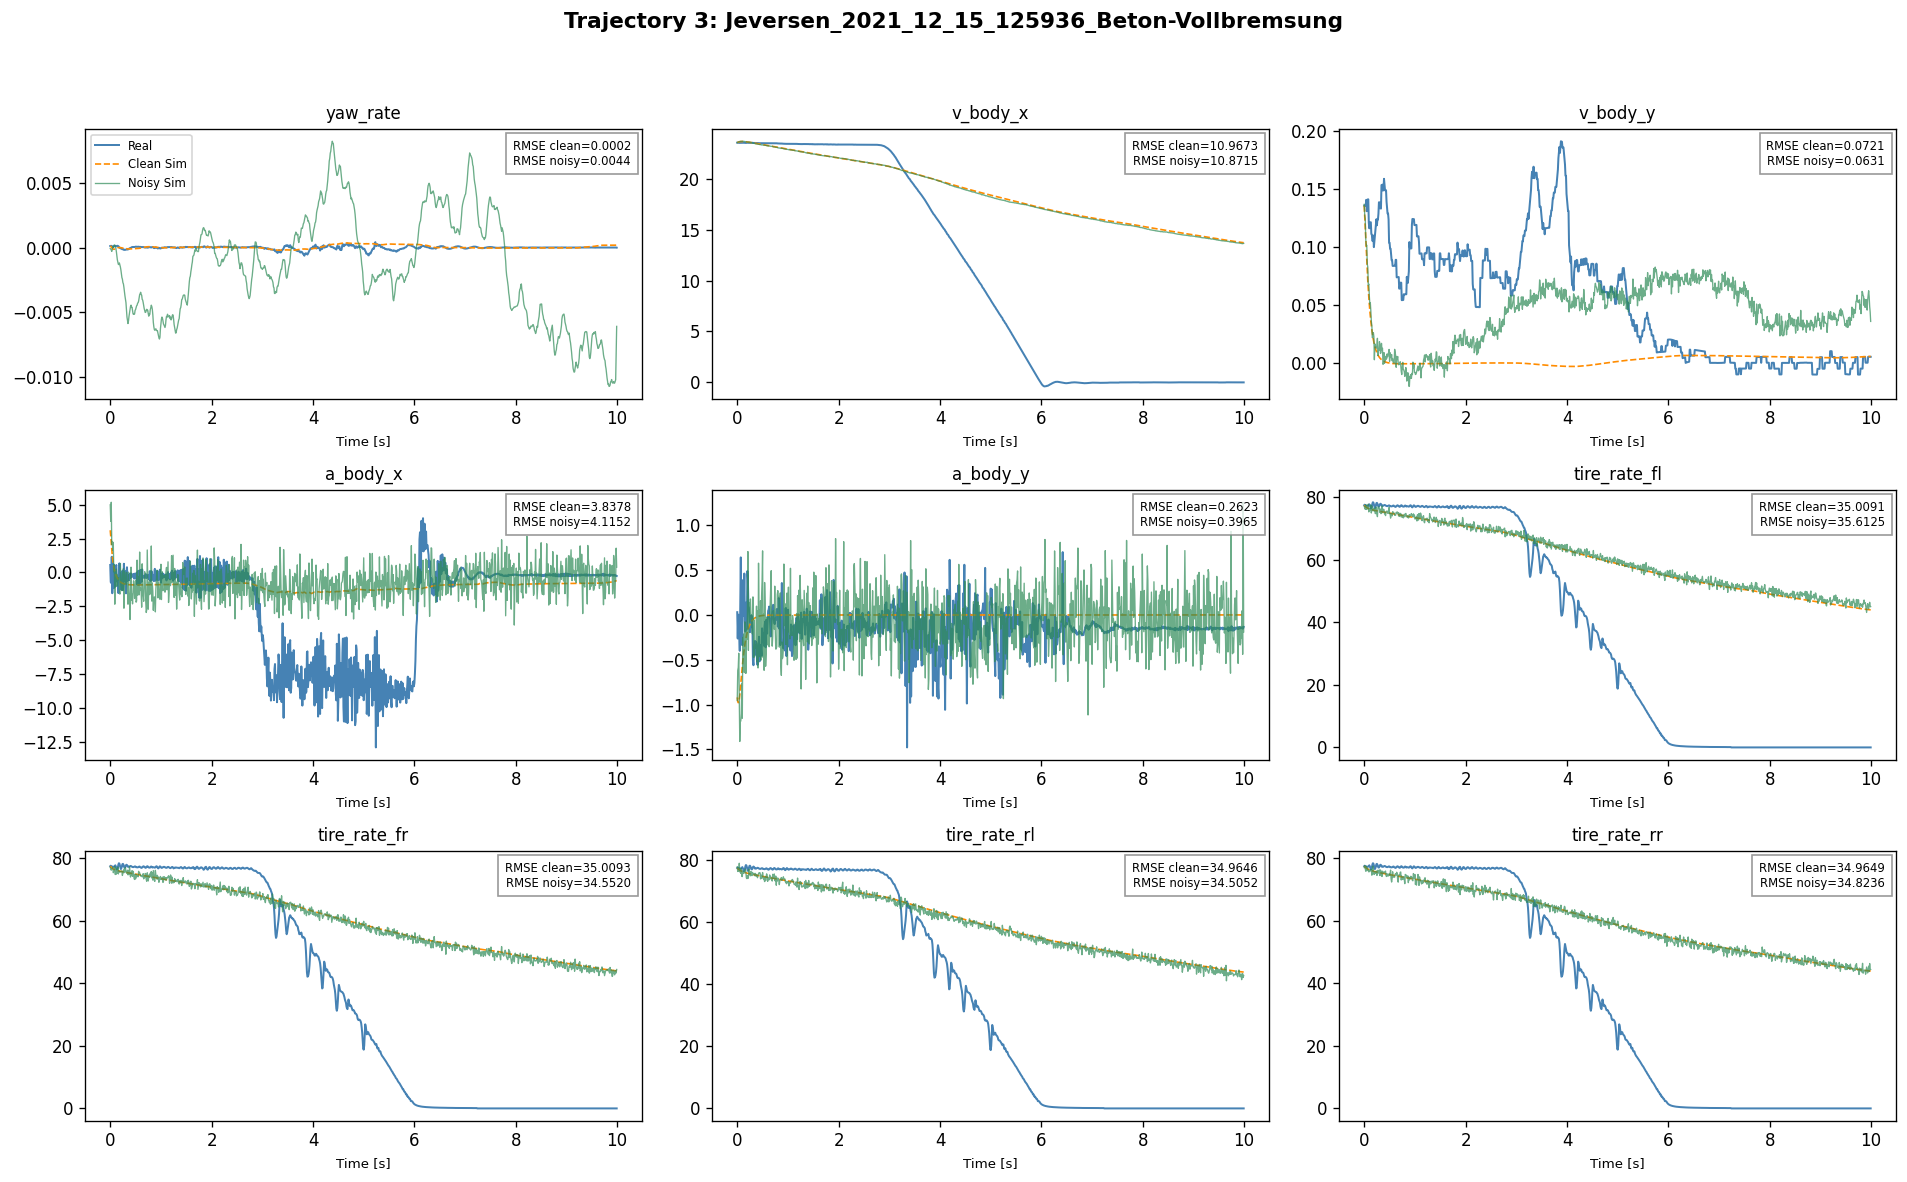


[Jeversen_2021_12_15_125936_Beton-Vollbremsung]  Weighted MSE  CleanSim=1702.223956  NoisySim=1691.238547


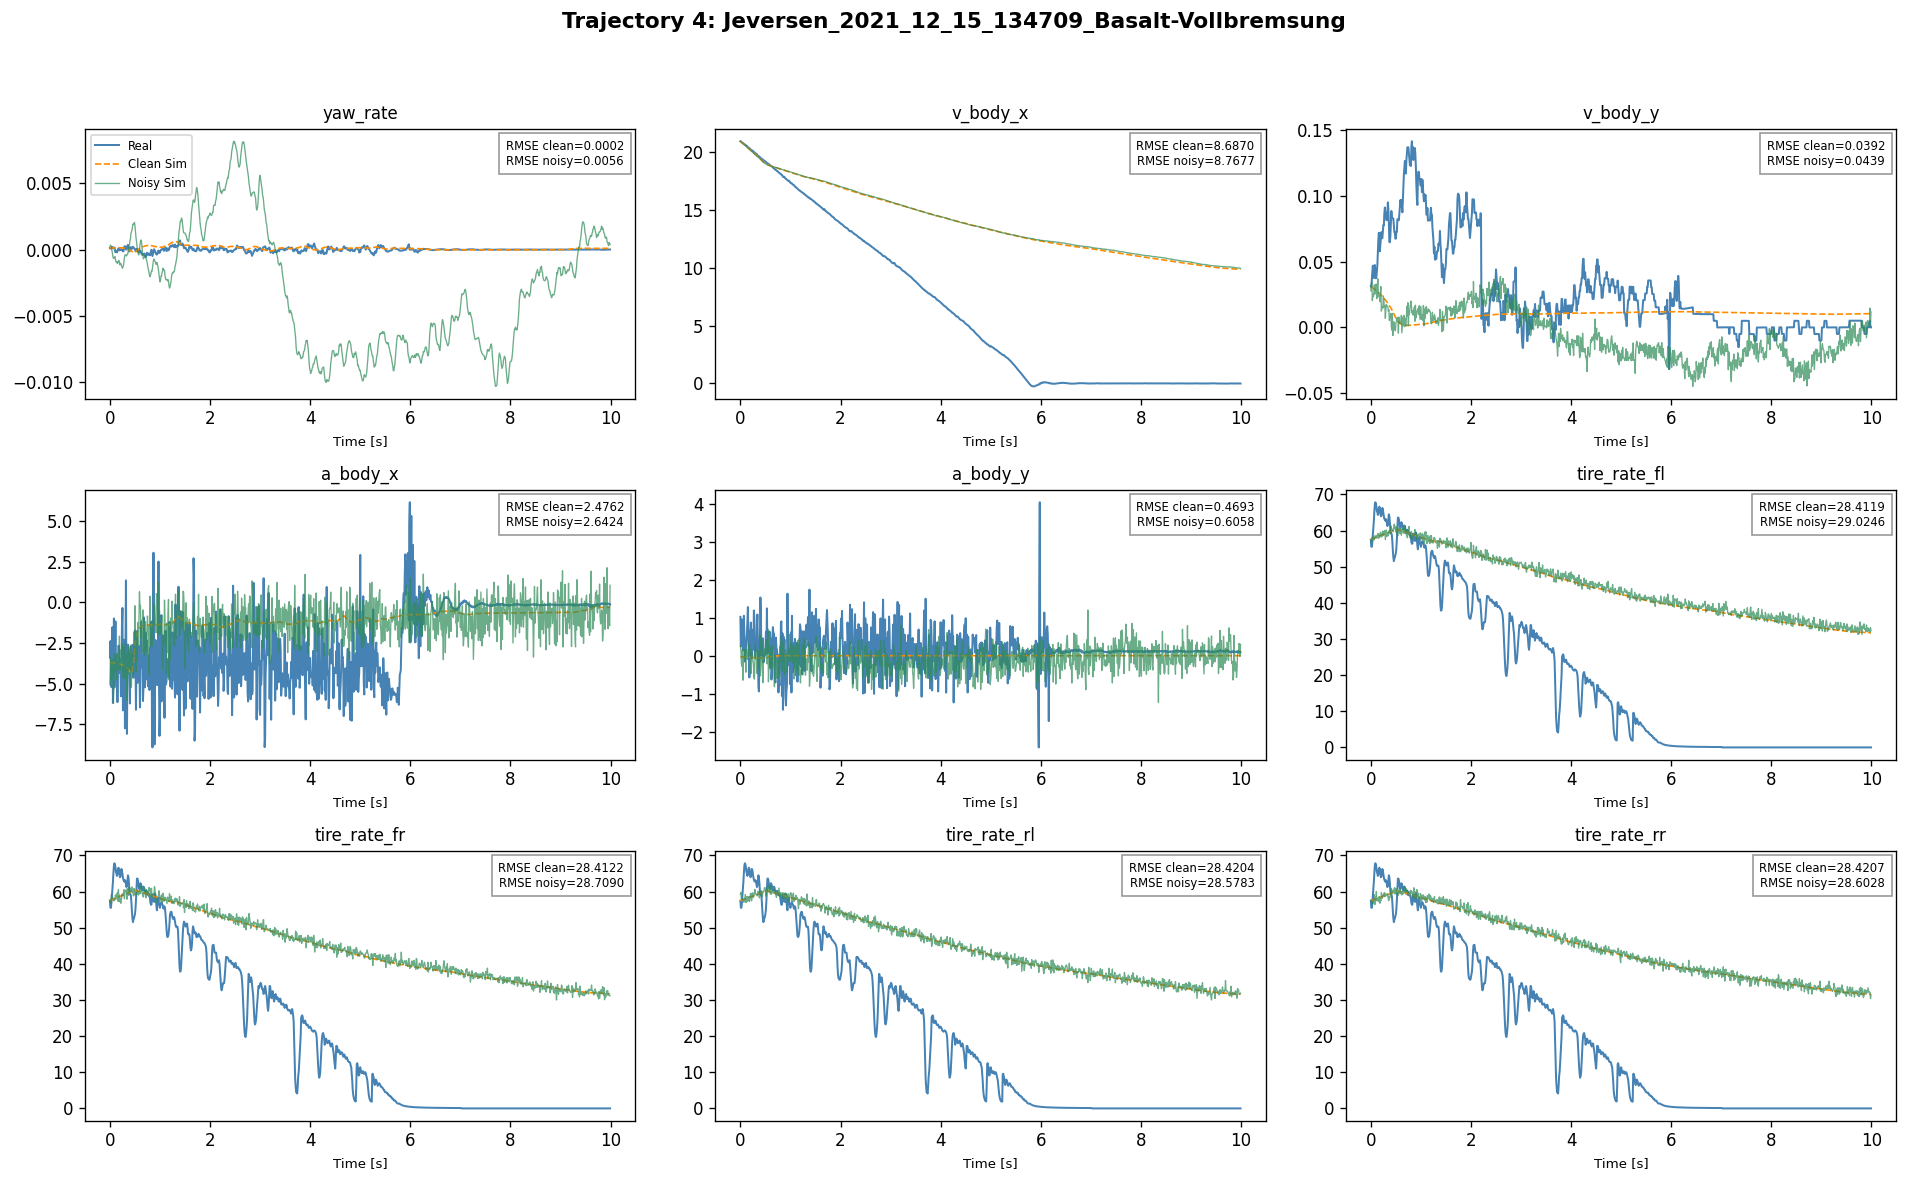


[Jeversen_2021_12_15_134709_Basalt-Vollbremsung]  Weighted MSE  CleanSim=1119.961021  NoisySim=1144.789265


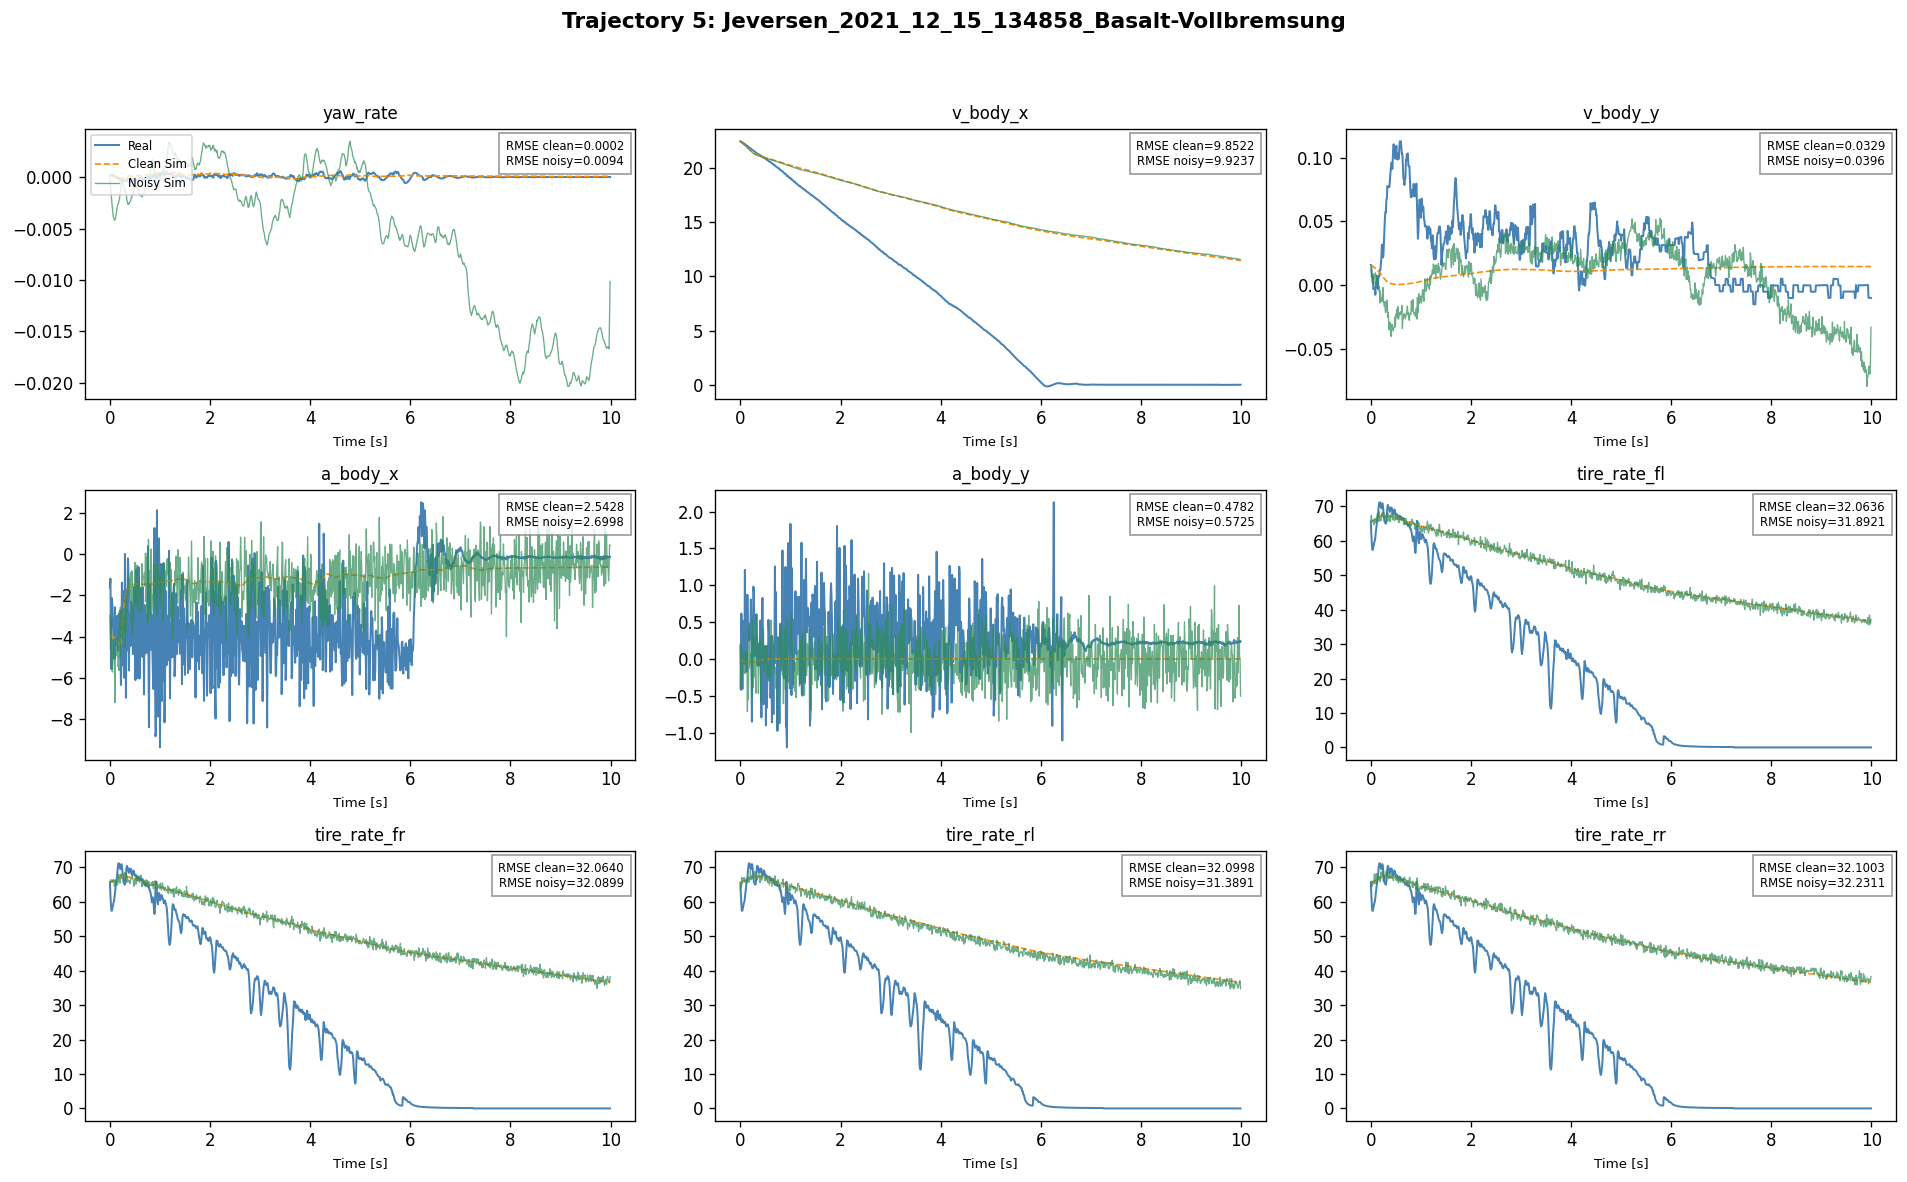


[Jeversen_2021_12_15_134858_Basalt-Vollbremsung]  Weighted MSE  CleanSim=1427.721665  NoisySim=1413.362206


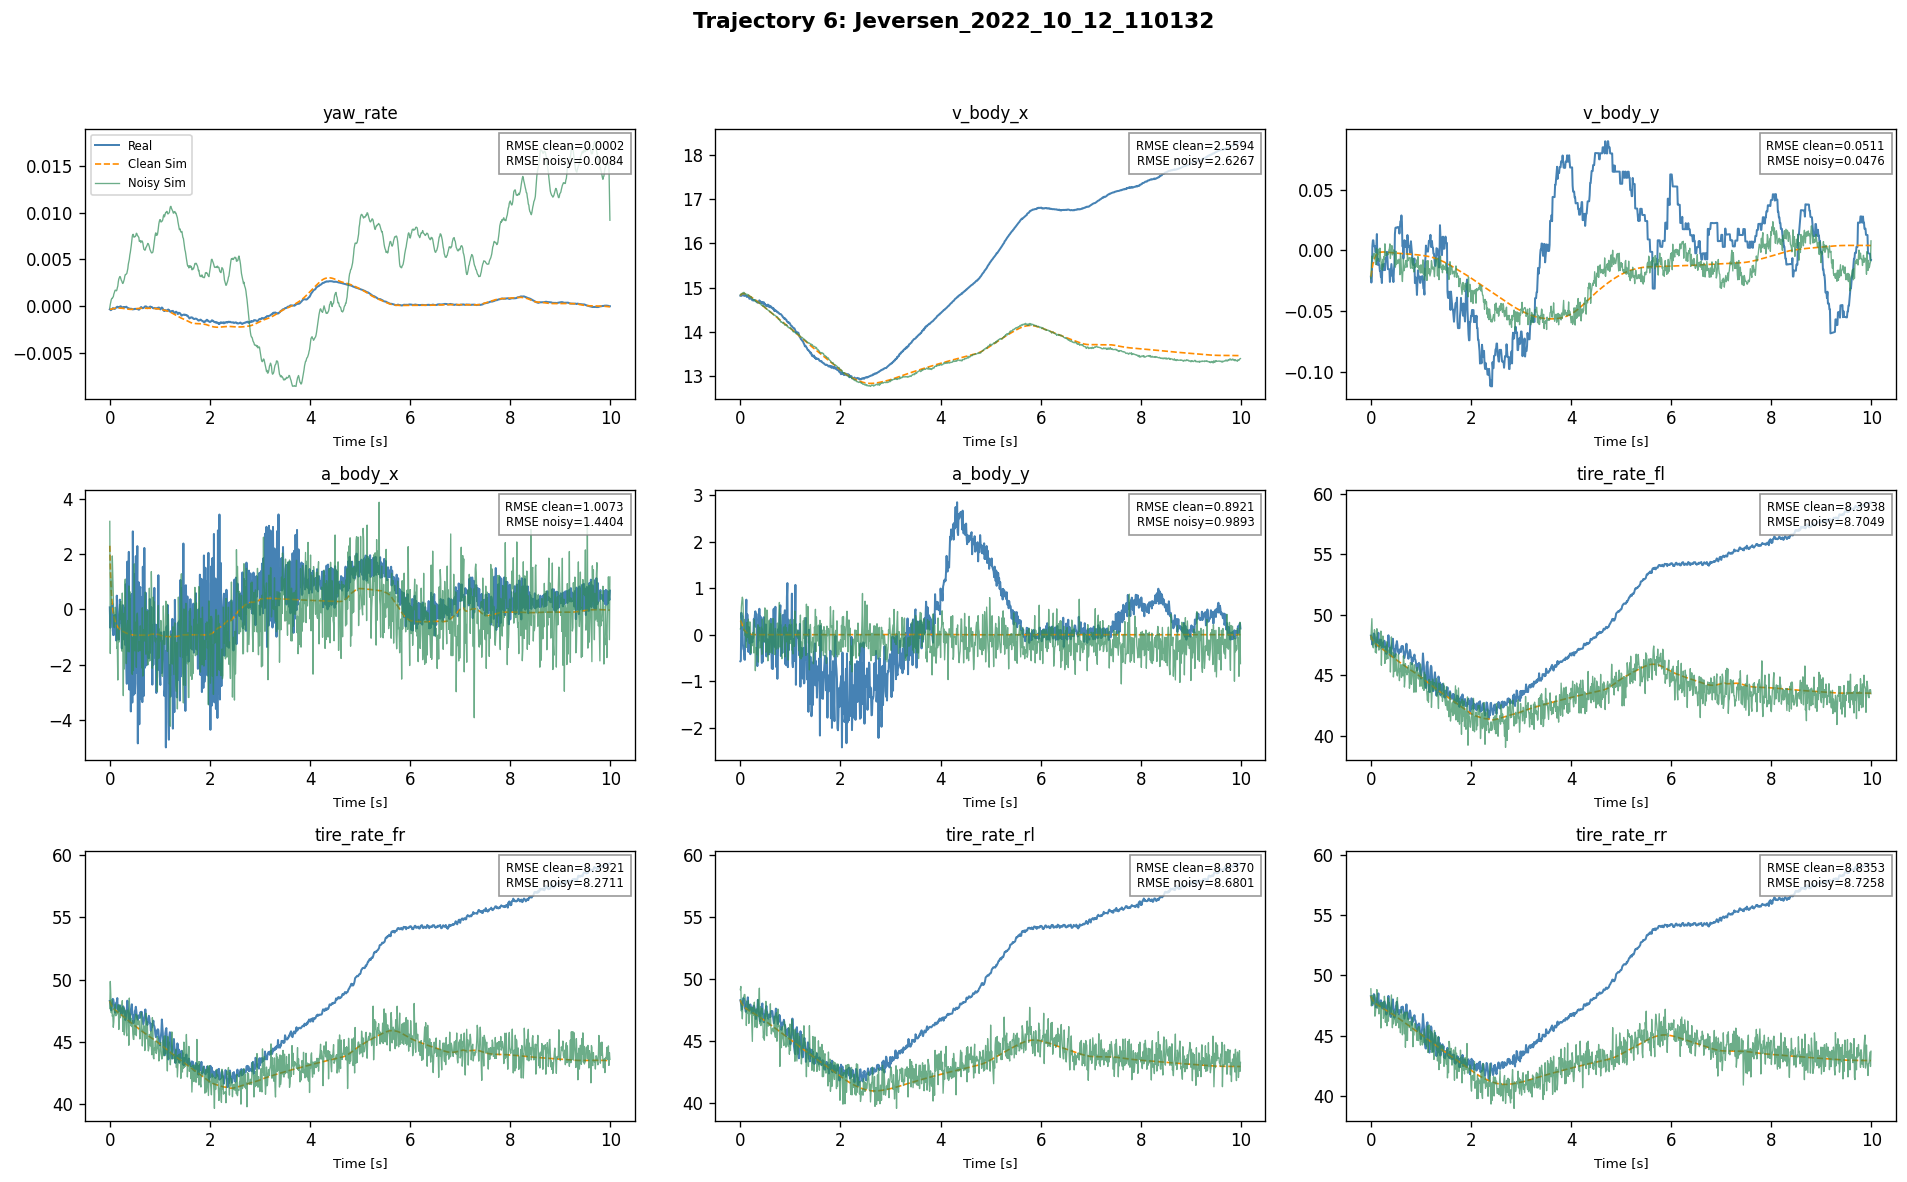


[Jeversen_2022_10_12_110132]  Weighted MSE  CleanSim=102.966005  NoisySim=102.960193

✓ Processed 7 real trajectories


In [15]:
from utils.real_data import initial_state_from_obs
from scipy.stats import ks_2samp, wasserstein_distance

# ── Settings ──────────────────────────────────────────────────────────────
OBS_WEIGHTS = np.array([1.0, 5.0, 1.0, 2.0, 1.0, 3.0, 3.0, 3.0, 3.0])

# Storage for cross-trajectory metrics
all_results = []

for traj_idx, csv_f in enumerate(csv_files):
    df_t = pd.read_csv(csv_f)
    T_use = min(T_EVENT, len(df_t))
    start = max(0, len(df_t) - T_use)

    # Real observations & controls
    x_obs = prep_x_obs_from_df(df_t, start, T_use).numpy()   # (T, 9)
    u_ctrl = make_controls_from_df(df_t, start, T_use)

    # Initial state from real data (same initial conditions)
    state0 = initial_state_from_obs(x_obs[0])

    # Forward simulate (clean)
    _, y_clean_jnp = rollout_with_states(p_inf, u_ctrl, state0=state0)
    y_clean = np.array(y_clean_jnp)

    # Forward simulate (noisy = process noise + obs noise)
    rng_t = np.random.default_rng(42 + traj_idx)
    y_proc  = add_process_noise(y_clean, rng_t, process_noise_scales, smoothing_window=5)
    y_noisy = add_observation_noise(y_proc, rng_t, obs_noise_std)

    # Per-channel RMSE
    rmse_clean = np.sqrt(np.mean((y_clean - x_obs) ** 2, axis=0))
    rmse_noisy = np.sqrt(np.mean((y_noisy - x_obs) ** 2, axis=0))
    wmse_clean = float(np.mean(OBS_WEIGHTS * rmse_clean ** 2))
    wmse_noisy = float(np.mean(OBS_WEIGHTS * rmse_noisy ** 2))

    all_results.append({
        'file': csv_f.name,
        'x_obs': x_obs,
        'y_clean': y_clean,
        'y_noisy': y_noisy,
        'rmse_clean': rmse_clean,
        'rmse_noisy': rmse_noisy,
        'wmse_clean': wmse_clean,
        'wmse_noisy': wmse_noisy,
        'T': T_use,
    })

    # ── 3×3 channel plot ──────────────────────────────────────────────
    fig, axes = plt.subplots(3, 3, figsize=(16, 10))
    fig.suptitle(f'Trajectory {traj_idx}: {csv_f.stem}', fontsize=13, fontweight='bold')
    t_ax = np.arange(T_use) * DT

    for ch, ax in enumerate(axes.flat):
        ax.plot(t_ax, x_obs[:, ch],  color='steelblue', lw=1.2, label='Real')
        ax.plot(t_ax, y_clean[:, ch], color='darkorange', lw=1.0, ls='--', label='Clean Sim')
        ax.plot(t_ax, y_noisy[:, ch], color='seagreen', lw=0.8, alpha=0.7, label='Noisy Sim')
        ax.set_title(OBS_LABELS[ch], fontsize=10)
        ax.set_xlabel('Time [s]', fontsize=8)
        rmse_c = rmse_clean[ch]
        rmse_n = rmse_noisy[ch]
        ax.text(0.98, 0.96, f'RMSE clean={rmse_c:.4f}\nRMSE noisy={rmse_n:.4f}',
                transform=ax.transAxes, fontsize=7, ha='right', va='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
        if ch == 0:
            ax.legend(fontsize=7, loc='upper left')

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    print(f'\n[{csv_f.stem}]  Weighted MSE  CleanSim={wmse_clean:.6f}  NoisySim={wmse_noisy:.6f}')

print(f'\n✓ Processed {len(all_results)} real trajectories')

## 14. Per-Channel RMSE Summary Table

Aggregate RMSE across all trajectories to see where clean sim fails and whether noise injection changes the error distribution meaningfully.

In [16]:
# ── Aggregate RMSE across all trajectories ────────────────────────────────
rmse_clean_all = np.stack([r['rmse_clean'] for r in all_results])  # (N_traj, 9)
rmse_noisy_all = np.stack([r['rmse_noisy'] for r in all_results])

print(f'{"Channel":20s}  {"Clean RMSE":>12s}  {"Noisy RMSE":>12s}  {"Δ RMSE":>10s}  {"Direction":>10s}')
print('=' * 75)
for ch in range(9):
    mc = rmse_clean_all[:, ch].mean()
    mn = rmse_noisy_all[:, ch].mean()
    delta = mn - mc
    direction = '▲ worse' if delta > 0 else '▼ better'
    print(f'{OBS_LABELS[ch]:20s}  {mc:12.6f}  {mn:12.6f}  {delta:+10.6f}  {direction:>10s}')

# Weighted MSE summary
wmse_c = np.array([r['wmse_clean'] for r in all_results])
wmse_n = np.array([r['wmse_noisy'] for r in all_results])
print(f'\n{"Weighted MSE":20s}  {wmse_c.mean():12.6f}  {wmse_n.mean():12.6f}  '
      f'{wmse_n.mean() - wmse_c.mean():+10.6f}  '
      f'{"▲ worse" if wmse_n.mean() > wmse_c.mean() else "▼ better":>10s}')

# Per-trajectory table
print(f'\n\n{"Trajectory":45s}  {"Clean wMSE":>12s}  {"Noisy wMSE":>12s}')
print('-' * 75)
for r in all_results:
    print(f'{r["file"][:45]:45s}  {r["wmse_clean"]:12.6f}  {r["wmse_noisy"]:12.6f}')

Channel                 Clean RMSE    Noisy RMSE      Δ RMSE   Direction
yaw_rate                  0.000229      0.008303   +0.008074     ▲ worse
v_body_x                  9.565355      9.558176   -0.007179    ▼ better
v_body_y                  0.043434      0.048214   +0.004780     ▲ worse
a_body_x                  3.002514      3.246721   +0.244207     ▲ worse
a_body_y                  0.467907      0.588004   +0.120097     ▲ worse
tire_rate_fl             30.797358     30.904491   +0.107134     ▲ worse
tire_rate_fr             30.797222     30.903166   +0.105944     ▲ worse
tire_rate_rl             30.860563     30.678329   -0.182234    ▼ better
tire_rate_rr             30.860432     30.983072   +0.122641     ▲ worse

Weighted MSE           1451.593095   1454.933231   +3.340136     ▲ worse


Trajectory                                       Clean wMSE    Noisy wMSE
---------------------------------------------------------------------------
Jeversen_2021_12_15_112145_Asphalt-Vollbrems

## 15. Cross-Trajectory RMSE Bar Chart

Visual comparison of weighted MSE per trajectory — clean sim vs noisy sim.

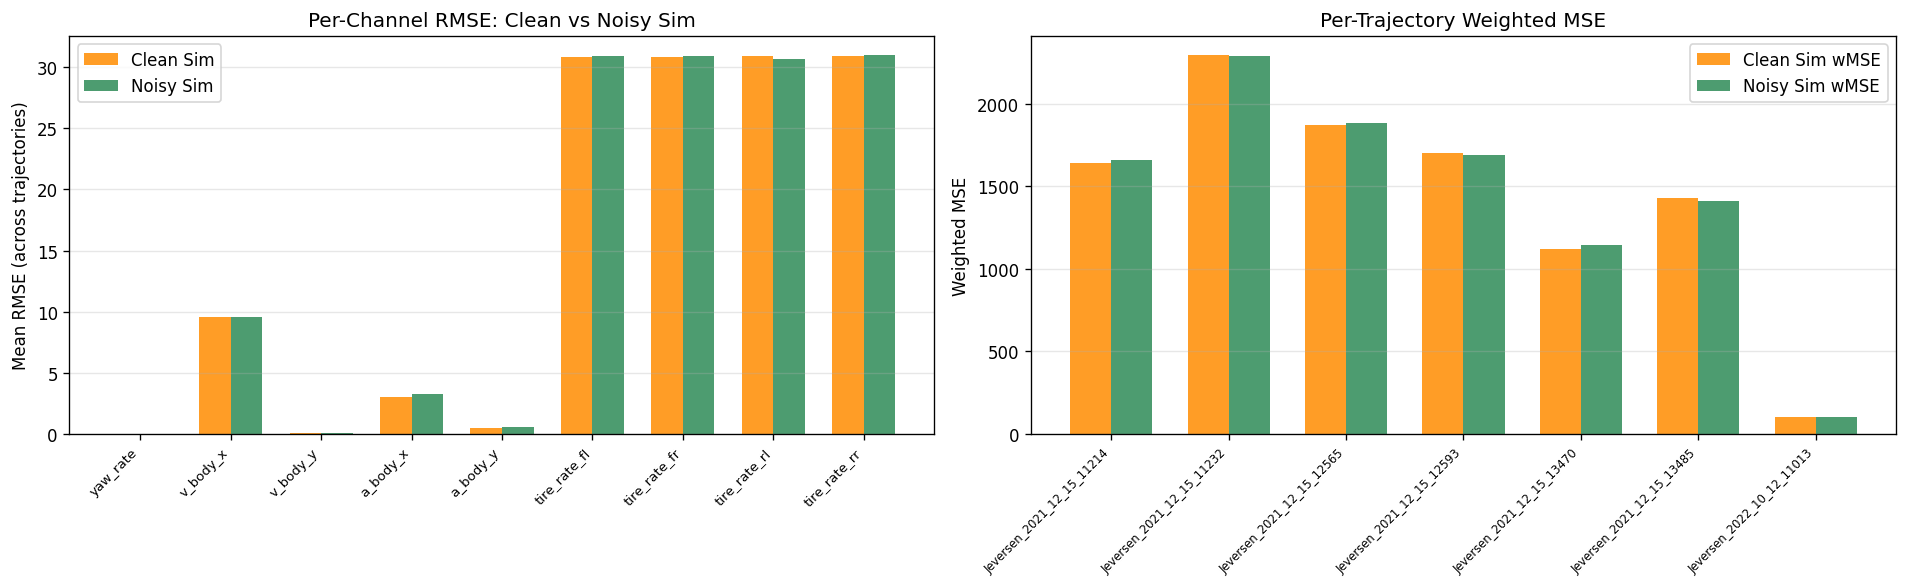

In [17]:
# ── Bar chart: per-channel mean RMSE (clean vs noisy) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Per-channel mean RMSE across trajectories
x_pos = np.arange(9)
width = 0.35
bars_c = rmse_clean_all.mean(axis=0)
bars_n = rmse_noisy_all.mean(axis=0)

axes[0].bar(x_pos - width/2, bars_c, width, label='Clean Sim', color='darkorange', alpha=0.85)
axes[0].bar(x_pos + width/2, bars_n, width, label='Noisy Sim', color='seagreen', alpha=0.85)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(OBS_LABELS, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Mean RMSE (across trajectories)')
axes[0].set_title('Per-Channel RMSE: Clean vs Noisy Sim')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# (b) Per-trajectory weighted MSE
traj_labels = [r['file'][:25] for r in all_results]
x_pos2 = np.arange(len(all_results))
axes[1].bar(x_pos2 - width/2, wmse_c, width, label='Clean Sim wMSE', color='darkorange', alpha=0.85)
axes[1].bar(x_pos2 + width/2, wmse_n, width, label='Noisy Sim wMSE', color='seagreen', alpha=0.85)
axes[1].set_xticks(x_pos2)
axes[1].set_xticklabels(traj_labels, rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel('Weighted MSE')
axes[1].set_title('Per-Trajectory Weighted MSE')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()

## 16. Distribution Overlap: KS Test & Wasserstein Distance

For each channel, we pool all trajectories and test whether the simulated distribution is statistically closer to the real distribution when noise is added.

- **KS statistic**: Lower = distributions overlap more (0 = identical CDFs)
- **Wasserstein distance**: Lower = less "work" to transform one distribution into the other
- **KS p-value**: Higher = cannot reject null that distributions are drawn from the same source

In [18]:
# Pool all trajectory data for distributional tests
real_pool  = np.concatenate([r['x_obs']   for r in all_results], axis=0)  # (N_total, 9)
clean_pool = np.concatenate([r['y_clean'] for r in all_results], axis=0)
noisy_pool = np.concatenate([r['y_noisy'] for r in all_results], axis=0)

print(f'Pooled samples: {real_pool.shape[0]:,}  ({len(all_results)} trajectories)\n')

print(f'{"Channel":20s}  {"KS_clean":>10s}  {"KS_noisy":>10s}  {"KS Δ":>8s}  '
      f'{"W_clean":>10s}  {"W_noisy":>10s}  {"W Δ":>8s}  {"Closer?":>8s}')
print('=' * 100)

ks_clean_arr, ks_noisy_arr = [], []
wd_clean_arr, wd_noisy_arr = [], []

for ch in range(9):
    r_ch = real_pool[:, ch]
    c_ch = clean_pool[:, ch]
    n_ch = noisy_pool[:, ch]

    ks_c, _ = ks_2samp(r_ch, c_ch)
    ks_n, _ = ks_2samp(r_ch, n_ch)
    wd_c = wasserstein_distance(r_ch, c_ch)
    wd_n = wasserstein_distance(r_ch, n_ch)

    ks_clean_arr.append(ks_c)
    ks_noisy_arr.append(ks_n)
    wd_clean_arr.append(wd_c)
    wd_noisy_arr.append(wd_n)

    ks_delta = ks_n - ks_c
    wd_delta = wd_n - wd_c
    closer = '✓' if (ks_delta < 0 and wd_delta < 0) else ('~' if ks_delta < 0 or wd_delta < 0 else '✗')
    print(f'{OBS_LABELS[ch]:20s}  {ks_c:10.4f}  {ks_n:10.4f}  {ks_delta:+8.4f}  '
          f'{wd_c:10.4f}  {wd_n:10.4f}  {wd_delta:+8.4f}  {closer:>8s}')

# Summary
ks_clean_arr = np.array(ks_clean_arr)
ks_noisy_arr = np.array(ks_noisy_arr)
n_improved_ks = np.sum(ks_noisy_arr < ks_clean_arr)
print(f'\nKS improved: {n_improved_ks}/9 channels')
print(f'Mean KS  clean={ks_clean_arr.mean():.4f}  noisy={ks_noisy_arr.mean():.4f}')
print(f'Mean Wasserstein  clean={np.mean(wd_clean_arr):.4f}  noisy={np.mean(wd_noisy_arr):.4f}')

Pooled samples: 7,000  (7 trajectories)

Channel                 KS_clean    KS_noisy      KS Δ     W_clean     W_noisy       W Δ   Closer?
yaw_rate                  0.1800      0.5134   +0.3334      0.0001      0.0067   +0.0066         ✗
v_body_x                  0.5264      0.5273   +0.0009      7.4718      7.4523   -0.0195         ~
v_body_y                  0.4777      0.3327   -0.1450      0.0253      0.0239   -0.0014         ✓
a_body_x                  0.4207      0.2737   -0.1470      2.0135      1.5338   -0.4797         ✓
a_body_y                  0.6149      0.1903   -0.4246      0.3242      0.1657   -0.1586         ✓
tire_rate_fl              0.5363      0.5370   +0.0007     24.3744     24.3740   -0.0005         ~
tire_rate_fr              0.5363      0.5324   -0.0039     24.3745     24.4727   +0.0981         ~
tire_rate_rl              0.5349      0.5344   -0.0004     24.3481     24.2341   -0.1140         ✓
tire_rate_rr              0.5350      0.5341   -0.0009     24.3482  

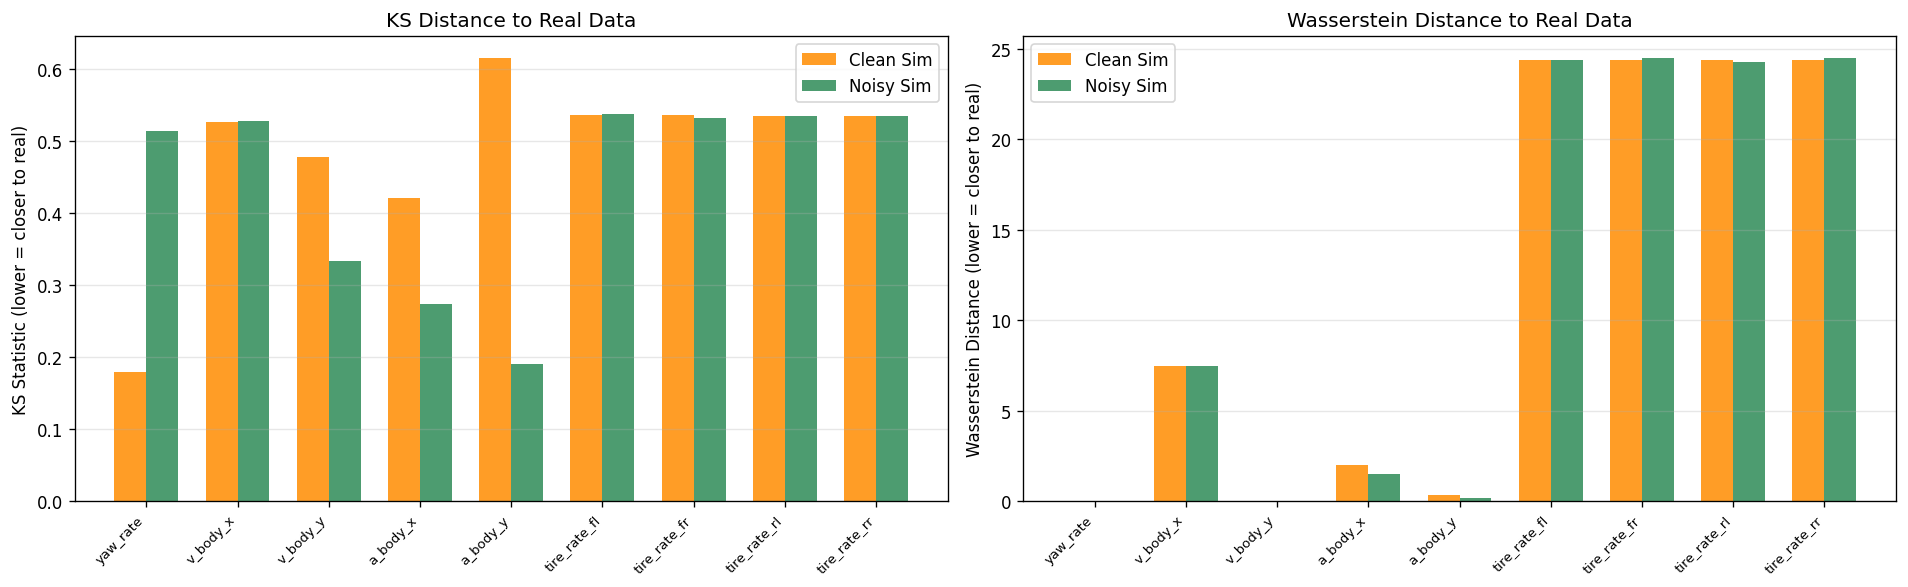

In [19]:
# ── Distribution overlap visualization ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x_pos = np.arange(9)
width = 0.35

axes[0].bar(x_pos - width/2, ks_clean_arr, width, label='Clean Sim', color='darkorange', alpha=0.85)
axes[0].bar(x_pos + width/2, ks_noisy_arr, width, label='Noisy Sim', color='seagreen', alpha=0.85)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(OBS_LABELS, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('KS Statistic (lower = closer to real)')
axes[0].set_title('KS Distance to Real Data')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x_pos - width/2, wd_clean_arr, width, label='Clean Sim', color='darkorange', alpha=0.85)
axes[1].bar(x_pos + width/2, wd_noisy_arr, width, label='Noisy Sim', color='seagreen', alpha=0.85)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(OBS_LABELS, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Wasserstein Distance (lower = closer to real)')
axes[1].set_title('Wasserstein Distance to Real Data')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()

## 17. Autocorrelation Structure Comparison

A key difference between real and simulated data is **temporal correlation**.
Real sensor signals have characteristic autocorrelation structure from physical dynamics + noise.
Clean sim is too smooth (autocorrelation decays too slowly).
We check whether adding noise makes the autocorrelation structure more realistic.

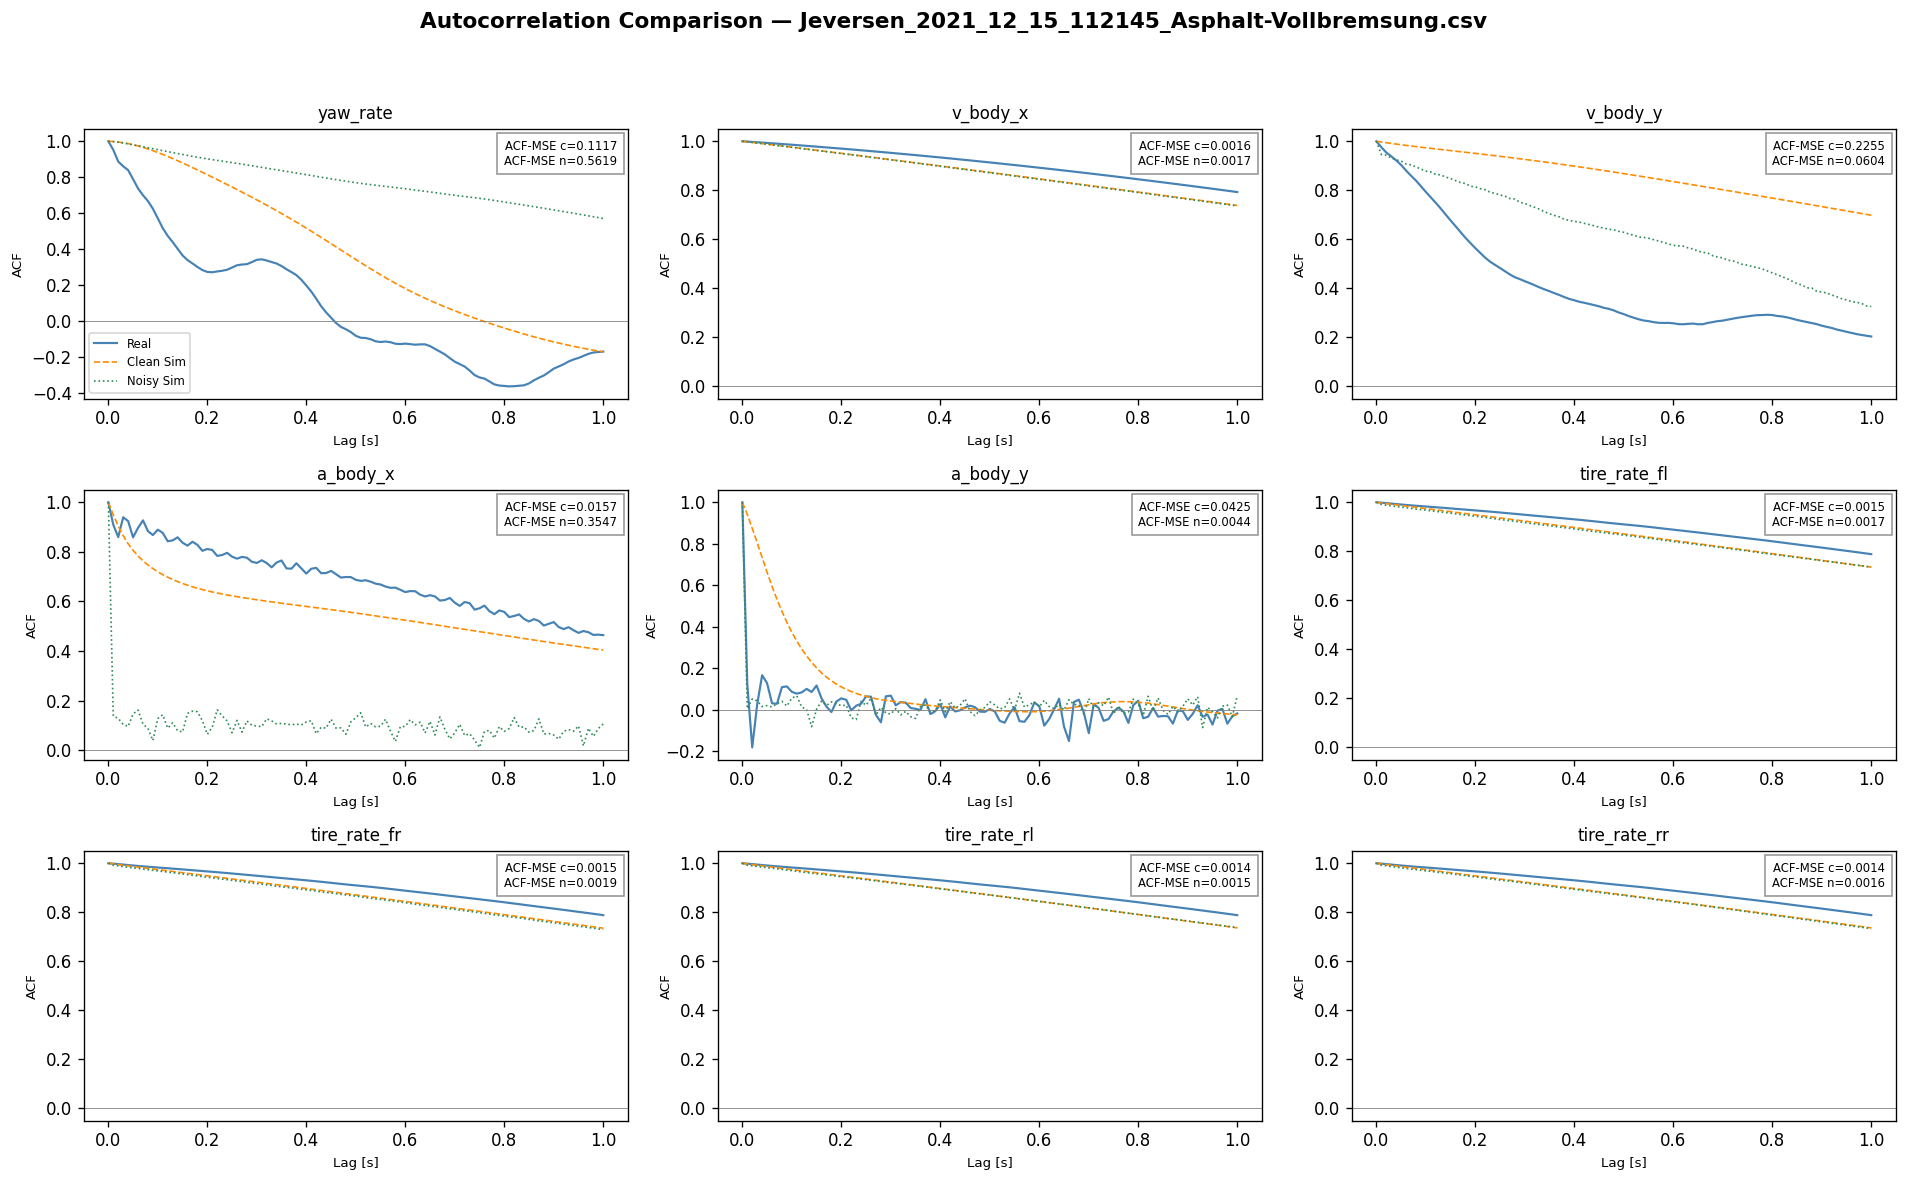


Autocorrelation MSE (vs real):
Channel                    Clean       Noisy           Δ   Closer?
yaw_rate                0.111739    0.561875   +0.450136         ✗
v_body_x                0.001571    0.001680   +0.000109         ✗
v_body_y                0.225462    0.060425   -0.165038         ✓
a_body_x                0.015653    0.354659   +0.339006         ✗
a_body_y                0.042524    0.004422   -0.038102         ✓
tire_rate_fl            0.001456    0.001716   +0.000259         ✗
tire_rate_fr            0.001456    0.001869   +0.000413         ✗
tire_rate_rl            0.001430    0.001461   +0.000031         ✗
tire_rate_rr            0.001430    0.001619   +0.000190         ✗

ACF improved: 2/9 channels


In [20]:
def autocorr(x, max_lag=100):
    """Compute normalized autocorrelation for lags 0..max_lag."""
    x = x - x.mean()
    variance = np.var(x)
    if variance < 1e-15:
        return np.zeros(max_lag + 1)
    result = np.correlate(x, x, mode='full')
    result = result[len(x) - 1:]  # keep non-negative lags
    result = result[:max_lag + 1] / (variance * len(x))
    return result

# Use first trajectory for detailed autocorrelation comparison
r0 = all_results[0]
max_lag = 100
lags = np.arange(max_lag + 1) * DT  # in seconds

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
fig.suptitle(f'Autocorrelation Comparison — {r0["file"]}', fontsize=13, fontweight='bold')

acf_mse_clean = []
acf_mse_noisy = []

for ch, ax in enumerate(axes.flat):
    acf_real  = autocorr(r0['x_obs'][:, ch],  max_lag)
    acf_clean = autocorr(r0['y_clean'][:, ch], max_lag)
    acf_noisy = autocorr(r0['y_noisy'][:, ch], max_lag)

    ax.plot(lags, acf_real,  color='steelblue', lw=1.3, label='Real')
    ax.plot(lags, acf_clean, color='darkorange', lw=1.0, ls='--', label='Clean Sim')
    ax.plot(lags, acf_noisy, color='seagreen', lw=1.0, ls=':', label='Noisy Sim')
    ax.set_title(OBS_LABELS[ch], fontsize=10)
    ax.set_xlabel('Lag [s]', fontsize=8)
    ax.set_ylabel('ACF', fontsize=8)
    ax.axhline(0, color='gray', lw=0.5, ls='-')

    # MSE of autocorrelation functions
    mse_c = np.mean((acf_real - acf_clean) ** 2)
    mse_n = np.mean((acf_real - acf_noisy) ** 2)
    acf_mse_clean.append(mse_c)
    acf_mse_noisy.append(mse_n)

    ax.text(0.98, 0.96, f'ACF-MSE c={mse_c:.4f}\nACF-MSE n={mse_n:.4f}',
            transform=ax.transAxes, fontsize=7, ha='right', va='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    if ch == 0:
        ax.legend(fontsize=7, loc='lower left')

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Summary
acf_mse_clean = np.array(acf_mse_clean)
acf_mse_noisy = np.array(acf_mse_noisy)
print(f'\nAutocorrelation MSE (vs real):')
print(f'{"Channel":20s}  {"Clean":>10s}  {"Noisy":>10s}  {"Δ":>10s}  {"Closer?":>8s}')
for ch in range(9):
    d = acf_mse_noisy[ch] - acf_mse_clean[ch]
    closer = '✓' if d < 0 else '✗'
    print(f'{OBS_LABELS[ch]:20s}  {acf_mse_clean[ch]:10.6f}  {acf_mse_noisy[ch]:10.6f}  '
          f'{d:+10.6f}  {closer:>8s}')
n_acf_improved = np.sum(acf_mse_noisy < acf_mse_clean)
print(f'\nACF improved: {n_acf_improved}/9 channels')

## 18. Difference-of-Differences: Does Noise Help SBI?

The key question for SBI: **does the noisy simulator produce training data whose _distribution_ better matches real data?**

We measure this with the **first-order temporal difference** distribution (Δx = x[t+1] - x[t]), which is what neural density estimators implicitly learn from sequential observations. If the difference distribution of noisy sim is closer to real than clean sim, then the simulator gap that SBI must bridge is smaller.

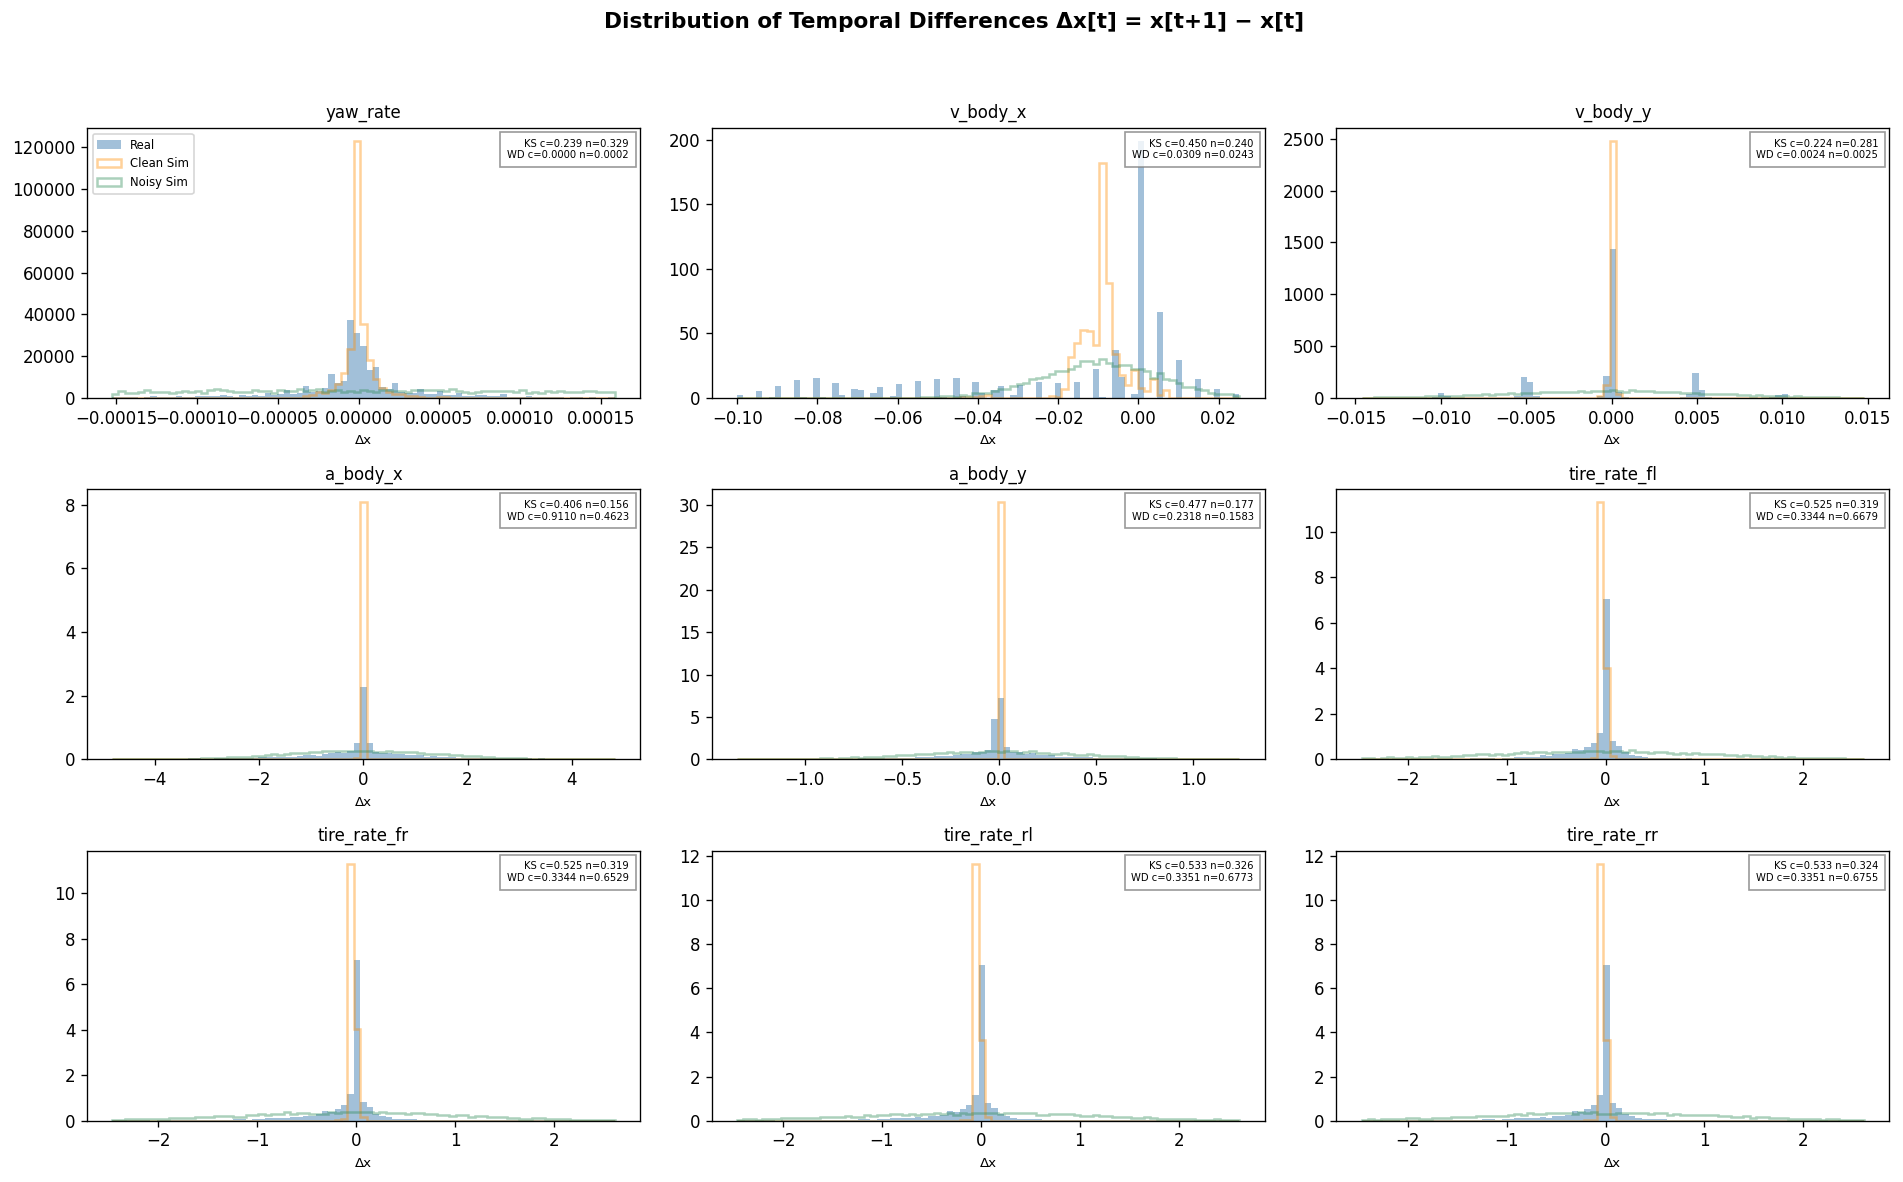


Temporal-Difference Distribution Tests:
Channel                 KS_clean    KS_noisy         Δ    WD_clean    WD_noisy         Δ
yaw_rate                  0.2395      0.3290   +0.0896      0.0000      0.0002   +0.0001
v_body_x                  0.4504      0.2403   -0.2100      0.0309      0.0243   -0.0065
v_body_y                  0.2242      0.2810   +0.0569      0.0024      0.0025   +0.0000
a_body_x                  0.4063      0.1563   -0.2500      0.9110      0.4623   -0.4488
a_body_y                  0.4771      0.1772   -0.2999      0.2318      0.1583   -0.0735
tire_rate_fl              0.5248      0.3188   -0.2060      0.3344      0.6679   +0.3334
tire_rate_fr              0.5249      0.3186   -0.2063      0.3344      0.6529   +0.3185
tire_rate_rl              0.5332      0.3265   -0.2067      0.3351      0.6773   +0.3422
tire_rate_rr              0.5332      0.3238   -0.2095      0.3351      0.6755   +0.3405

Diff-KS improved: 7/9 channels


In [21]:
# ── First-order temporal differences ───────────────────────────────────────
diff_real  = np.diff(real_pool,  axis=0)
diff_clean = np.diff(clean_pool, axis=0)
diff_noisy = np.diff(noisy_pool, axis=0)

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
fig.suptitle('Distribution of Temporal Differences Δx[t] = x[t+1] − x[t]', fontsize=13, fontweight='bold')

diff_ks_clean, diff_ks_noisy = [], []
diff_wd_clean, diff_wd_noisy = [], []

for ch, ax in enumerate(axes.flat):
    dr = diff_real[:, ch]
    dc = diff_clean[:, ch]
    dn = diff_noisy[:, ch]

    # Histogram overlay
    bins = np.linspace(np.percentile(dr, 1), np.percentile(dr, 99), 80)
    ax.hist(dr, bins=bins, density=True, alpha=0.5, color='steelblue', label='Real')
    ax.hist(dc, bins=bins, density=True, alpha=0.4, color='darkorange', label='Clean Sim', histtype='step', lw=1.5)
    ax.hist(dn, bins=bins, density=True, alpha=0.4, color='seagreen', label='Noisy Sim', histtype='step', lw=1.5)
    ax.set_title(OBS_LABELS[ch], fontsize=10)
    ax.set_xlabel('Δx', fontsize=8)

    # KS + Wasserstein on diffs
    ks_c, _ = ks_2samp(dr, dc)
    ks_n, _ = ks_2samp(dr, dn)
    wd_c = wasserstein_distance(dr, dc)
    wd_n = wasserstein_distance(dr, dn)
    diff_ks_clean.append(ks_c)
    diff_ks_noisy.append(ks_n)
    diff_wd_clean.append(wd_c)
    diff_wd_noisy.append(wd_n)

    ax.text(0.98, 0.96, f'KS c={ks_c:.3f} n={ks_n:.3f}\nWD c={wd_c:.4f} n={wd_n:.4f}',
            transform=ax.transAxes, fontsize=6, ha='right', va='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    if ch == 0:
        ax.legend(fontsize=7)

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Summary table
print(f'\nTemporal-Difference Distribution Tests:')
print(f'{"Channel":20s}  {"KS_clean":>10s}  {"KS_noisy":>10s}  {"Δ":>8s}  '
      f'{"WD_clean":>10s}  {"WD_noisy":>10s}  {"Δ":>8s}')
print('=' * 85)
for ch in range(9):
    ks_d = diff_ks_noisy[ch] - diff_ks_clean[ch]
    wd_d = diff_wd_noisy[ch] - diff_wd_clean[ch]
    print(f'{OBS_LABELS[ch]:20s}  {diff_ks_clean[ch]:10.4f}  {diff_ks_noisy[ch]:10.4f}  {ks_d:+8.4f}  '
          f'{diff_wd_clean[ch]:10.4f}  {diff_wd_noisy[ch]:10.4f}  {wd_d:+8.4f}')

n_diff_improved = sum(1 for ch in range(9) if diff_ks_noisy[ch] < diff_ks_clean[ch])
print(f'\nDiff-KS improved: {n_diff_improved}/9 channels')

## 19. Overall Assessment

In [22]:
# ── Comprehensive scorecard ────────────────────────────────────────────────
print('=' * 80)
print('  COMPREHENSIVE VALIDATION SCORECARD')
print('=' * 80)

# 1. Trajectory RMSE
print('\n1. TRAJECTORY RMSE (real controls, real initial states)')
print(f'   Mean Weighted MSE:  Clean = {wmse_c.mean():.6f}   Noisy = {wmse_n.mean():.6f}')
if wmse_n.mean() > wmse_c.mean():
    print(f'   → Noise INCREASES point-wise error (expected for stochastic noise)')
    print(f'   → This is NOT a problem: SBI cares about distributional match, not point-wise fit')
else:
    print(f'   → Noise decreases point-wise error')

# 2. Distribution overlap
print(f'\n2. DISTRIBUTIONAL MATCH (KS + Wasserstein on marginals)')
n_ks_better = int(np.sum(ks_noisy_arr < ks_clean_arr))
print(f'   KS closer in {n_ks_better}/9 channels')
print(f'   Mean KS:  Clean = {ks_clean_arr.mean():.4f}   Noisy = {ks_noisy_arr.mean():.4f}')

# 3. Temporal difference distribution
print(f'\n3. TEMPORAL DIFFERENCE DISTRIBUTION (most relevant for SBI)')
n_diff_ks_better = sum(1 for ch in range(9) if diff_ks_noisy[ch] < diff_ks_clean[ch])
n_diff_wd_better = sum(1 for ch in range(9) if diff_wd_noisy[ch] < diff_wd_clean[ch])
print(f'   Diff-KS closer in {n_diff_ks_better}/9 channels')
print(f'   Diff-WD closer in {n_diff_wd_better}/9 channels')

# 4. Autocorrelation match
print(f'\n4. AUTOCORRELATION STRUCTURE')
print(f'   ACF-MSE closer in {int(n_acf_improved)}/9 channels')
print(f'   Mean ACF-MSE:  Clean = {acf_mse_clean.mean():.6f}   Noisy = {acf_mse_noisy.mean():.6f}')

# 5. Overall verdict
print('\n' + '=' * 80)
total_wins = n_diff_ks_better + n_diff_wd_better + int(n_acf_improved) + n_ks_better
total_tests = 9 * 4
print(f'  TOTAL IMPROVEMENT SCORE: {total_wins}/{total_tests} channel-tests show noise helps')
pct = 100 * total_wins / total_tests
if pct > 60:
    verdict = 'Noise injection MEANINGFULLY improves sim-to-real distributional match'
elif pct > 40:
    verdict = 'Noise injection has MIXED effects — some channels benefit, others worsen'
else:
    verdict = 'Noise injection does NOT conclusively improve distributional match'
print(f'  VERDICT: {verdict}')
print(f'\n  KEY INSIGHT: The trajectory RMSE test measures point-wise accuracy')
print(f'  (which noise hurts by design). The distributional tests measure')
print(f'  whether simulated data "looks like" real data statistically,')
print(f'  which is what matters for training SBI posterior estimators.')
print('=' * 80)

  COMPREHENSIVE VALIDATION SCORECARD

1. TRAJECTORY RMSE (real controls, real initial states)
   Mean Weighted MSE:  Clean = 1451.593095   Noisy = 1454.933231
   → Noise INCREASES point-wise error (expected for stochastic noise)
   → This is NOT a problem: SBI cares about distributional match, not point-wise fit

2. DISTRIBUTIONAL MATCH (KS + Wasserstein on marginals)
   KS closer in 6/9 channels
   Mean KS:  Clean = 0.4847   Noisy = 0.4417

3. TEMPORAL DIFFERENCE DISTRIBUTION (most relevant for SBI)
   Diff-KS closer in 7/9 channels
   Diff-WD closer in 3/9 channels

4. AUTOCORRELATION STRUCTURE
   ACF-MSE closer in 2/9 channels
   Mean ACF-MSE:  Clean = 0.044747   Noisy = 0.109969

  TOTAL IMPROVEMENT SCORE: 18/36 channel-tests show noise helps
  VERDICT: Noise injection has MIXED effects — some channels benefit, others worsen

  KEY INSIGHT: The trajectory RMSE test measures point-wise accuracy
  (which noise hurts by design). The distributional tests measure
  whether simulated dat